# Experiments 
In this notebook we'll develop some experiments about the performance of LSTM architecture vs TimesFM.

__Content__:
1. Load data and preparate for training
2. Train LSTM
3. Train TimesFM
4. Save results and discussion


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from matplotlib.ticker import MaxNLocator

loss_folder = 'C:/Users/criju/Documents/Codigos Tesis/loss_plots'
os.makedirs(loss_folder, exist_ok=True)

es_cb = EarlyStopping(
    monitor='loss',
    patience=10,
    restore_best_weights=True
)

## 1. Train LSTM 
Now we'll train LSTM with 3 windows sizes (7,14,21), 2 different forecast horizon (15,30) and for each interval we add the previous one.

In [17]:
# Load the dataset
df =  pd.read_csv('C:/Users/criju/Documents/Codigos Tesis/data/serie.csv')
df['Fecha'] = pd.to_datetime(df['Fecha'])

# Functions for data processing and model building
def create_intervals(df):
    """
    Divide un DataFrame en 8 intervalos regulares basados en la columna 'Fecha',
    grafica los datos y devuelve los intervalos.
    """
    fecha_min = df['Fecha'].min()
    fecha_max = df['Fecha'].max()
    bins = pd.date_range(start=fecha_min, end=fecha_max, periods=9)  # 9 puntos para generar 8 intervalos
    df['Intervalo'] = pd.cut(df['Fecha'], bins=bins, include_lowest=True, right=False)
    intervalos_ordenados = sorted(df['Intervalo'].dropna().unique(), key=lambda x: x.left)
    return intervalos_ordenados

def build_lstm_model(window_size):
    model = Sequential([
        LSTM(32, activation='relu', input_shape=(window_size, 1), dropout=0.2),
        Dense(32),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model


def create_windows(data, window_size):
    """
    Genera secuencias (ventanas) a partir de la serie de tiempo.
    
    Args:
        data (np.array): Valores escalados de la serie.
        window_size (int): Longitud de la ventana.
        
    Returns:
        tuple: Arrays (x, y) donde x son las secuencias y y el valor a predecir.
    """
    x = []
    y = []
    for i in range(len(data) - window_size):
        x.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(x), np.array(y)

def smape(y_true, y_pred, eps=1e-8):
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return 100 * np.mean(numerator / (denominator + eps))

In [18]:
# Review the numbers of parameters of LSTM
model = build_lstm_model(window_size=7)
model.summary()

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,441 (21.25 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 0 (0.00 B)

### Train for windows size = 7


Iteración 1: Mejor época = 16, Loss = 0.0009
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Acumulando intervalos 1 a 1: MAE = 95.00, MSE = 14151.56


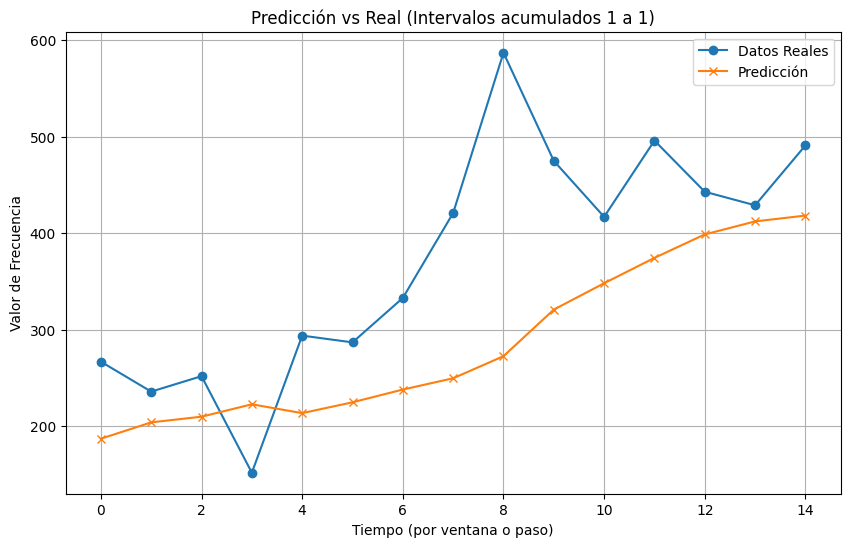

Iteración 2: Mejor época = 2, Loss = 0.0223
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Acumulando intervalos 1 a 2: MAE = 116.28, MSE = 22753.10


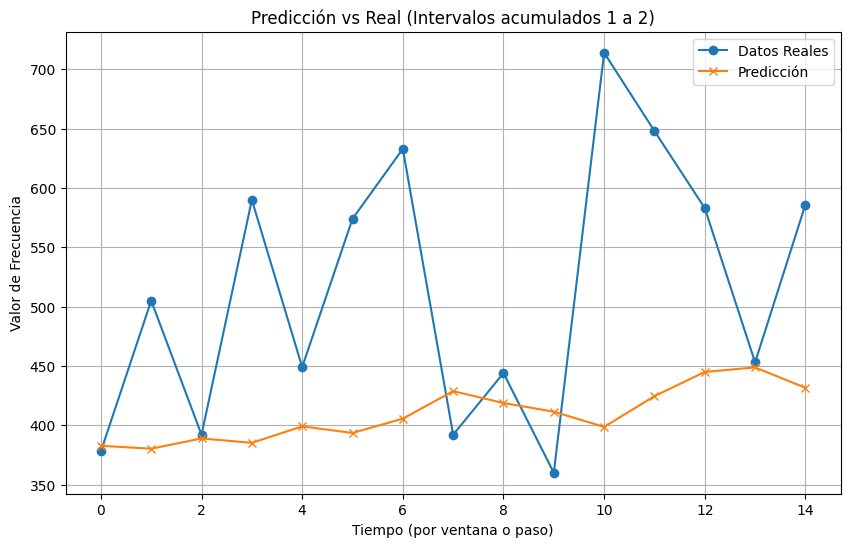

Iteración 3: Mejor época = 14, Loss = 0.0065
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 3: MAE = 294.72, MSE = 134022.37


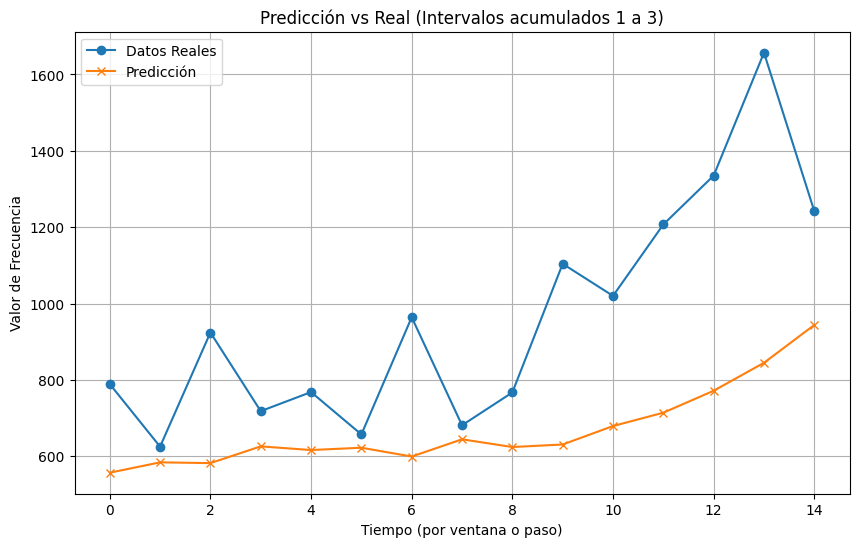

Iteración 4: Mejor época = 9, Loss = 0.0098
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 4: MAE = 189.01, MSE = 35791.92


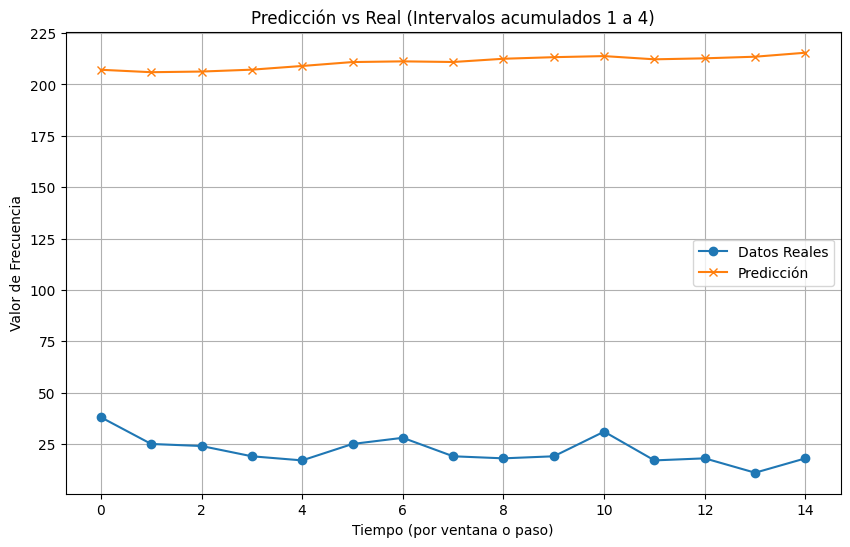

Iteración 5: Mejor época = 1, Loss = 0.0093
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 5: MAE = 91.88, MSE = 11538.50


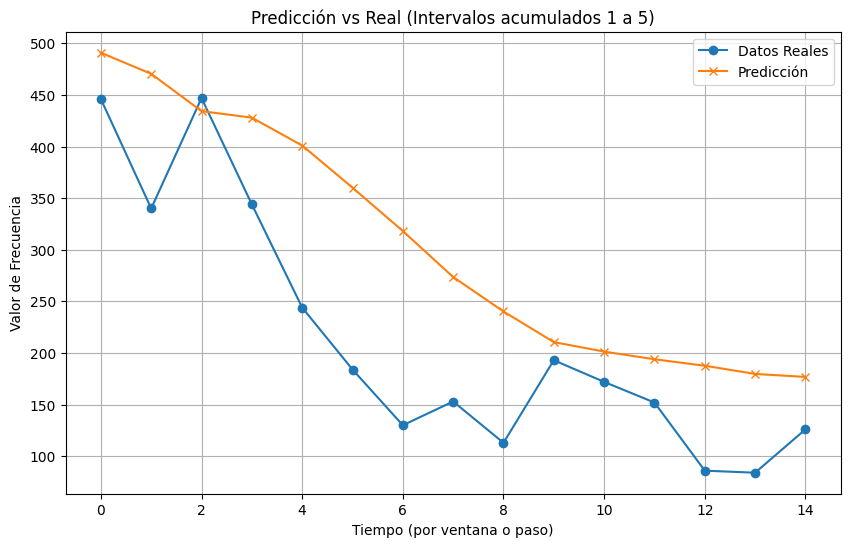

Iteración 6: Mejor época = 18, Loss = 0.0074
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 6: MAE = 45.03, MSE = 2448.15


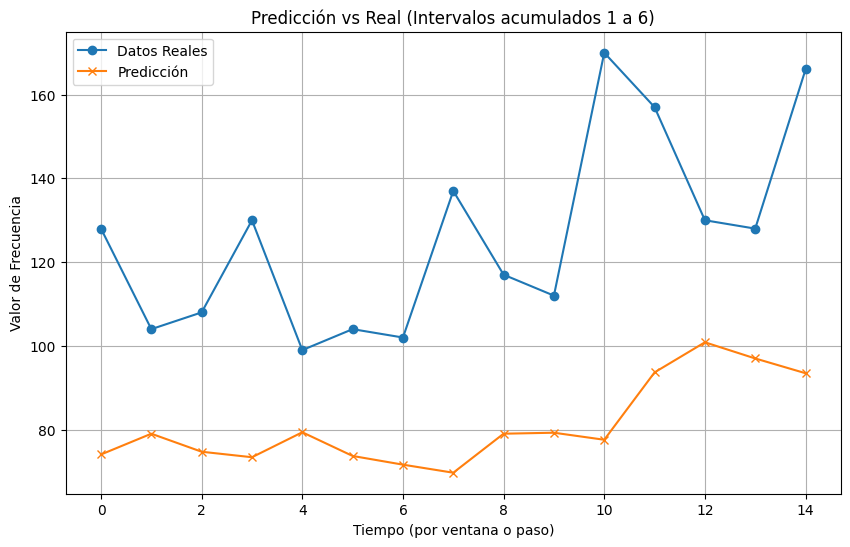

Iteración 7: Mejor época = 5, Loss = 0.0059
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 7: MAE = 31.03, MSE = 1437.12


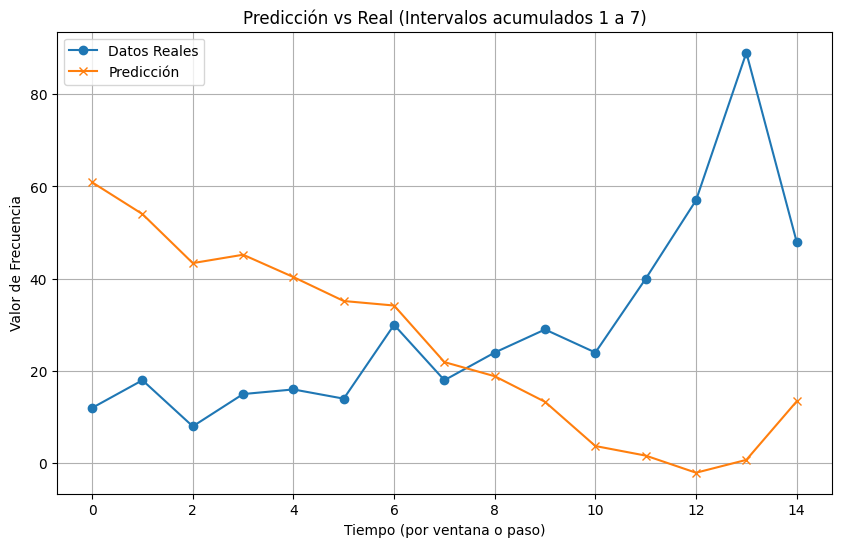

Iteración 8: Mejor época = 17, Loss = 0.0054
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Acumulando intervalos 1 a 8: MAE = 14.34, MSE = 266.87


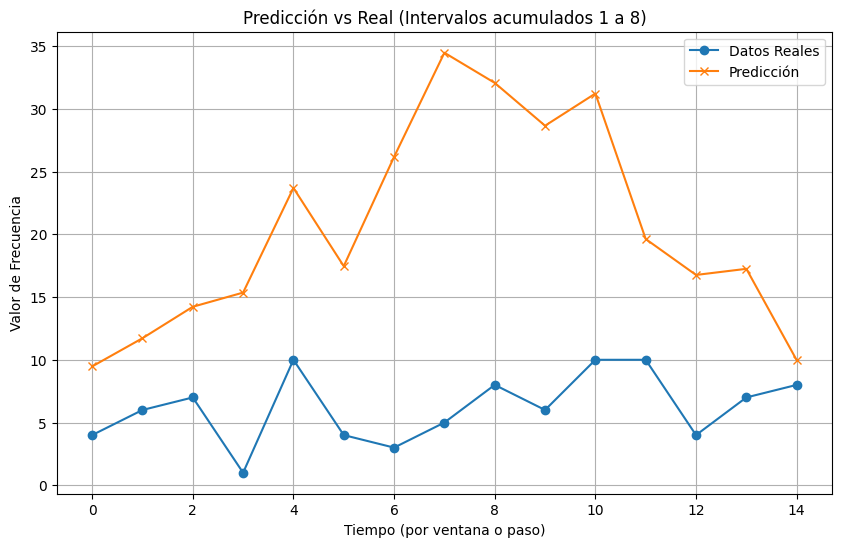


Resumen de métricas:
  Intervalos Acumulados         MAE            MSE       SMAPE
0      Intervalos 1 a 1   95.000027   14151.561377   28.924127
1      Intervalos 1 a 2  116.282552   22753.096355   23.317602
2      Intervalos 1 a 3  294.717542  134022.369930   32.832632
3      Intervalos 1 a 4  189.013595   35791.923381  162.743569
4      Intervalos 1 a 5   91.881662   11538.497477   41.433634
5      Intervalos 1 a 6   45.025281    2448.150179   42.377617
6      Intervalos 1 a 7   31.034034    1437.122105  107.687771
7      Intervalos 1 a 8   14.342756     266.867883  103.510213


In [19]:
# Parameters
WINDOW_SIZE = 7
HORIZONTE = 15 
EPOCHS = 50          
BATCH_SIZE = 16     
intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es_cb],
        verbose=0
    )
    
    # Se añade logica de la función de perdida
    # 1) Encuentro la época de mínima pérdida
    loss_vals = history.history['loss']
    epochs_ran = len(loss_vals) 
    best_epoch = int(np.argmin(loss_vals)) + 1         # +1 porque los epochs comienzan en 1
    best_loss = loss_vals[best_epoch-1]
    print(f"Iteración {i+1}: Mejor época = {best_epoch}, Loss = {best_loss:.4f}")

    # 2) Grafico la curva de entrenamiento y marco la mejor época
    plt.figure(figsize=(8,5))
    ax = plt.gca()  # obtenemos el eje actual
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
    plt.plot(range(1, epochs_ran+1), loss_vals, marker='o', label='Training loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
    plt.title(f"Pérdida durante el entrenamiento\nIntervalos 1 a {i+1}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 3) Guardo la figura en la carpeta
    plot_path = os.path.join(loss_folder, f"7_15_loss_intervalos_1_{i+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close() 

    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_3/lstm_7_15.csv', index=False)

Iteración 1: Mejor época = 22, Loss = 0.0002
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Acumulando intervalos 1 a 1: MAE = 56.70, MSE = 6234.01


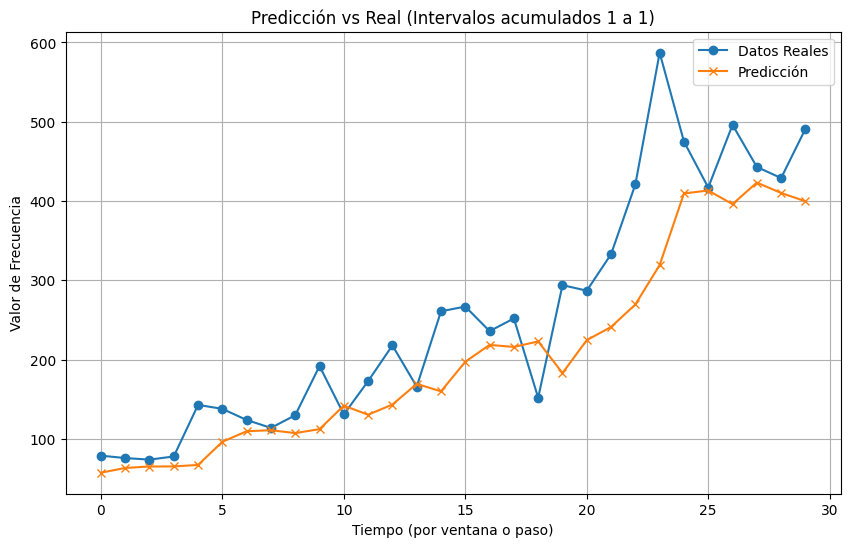

Iteración 2: Mejor época = 9, Loss = 0.0192
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 2: MAE = 93.61, MSE = 15642.03


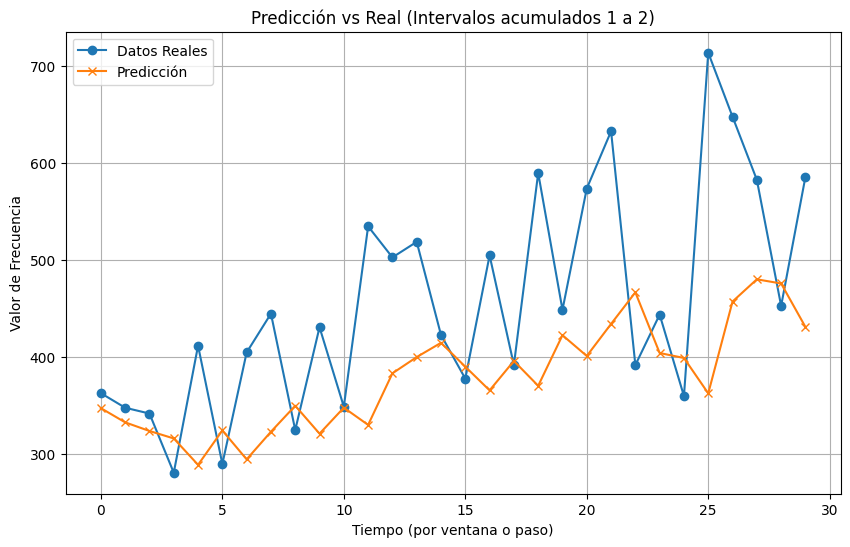

Iteración 3: Mejor época = 17, Loss = 0.0056
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 3: MAE = 223.49, MSE = 83977.97


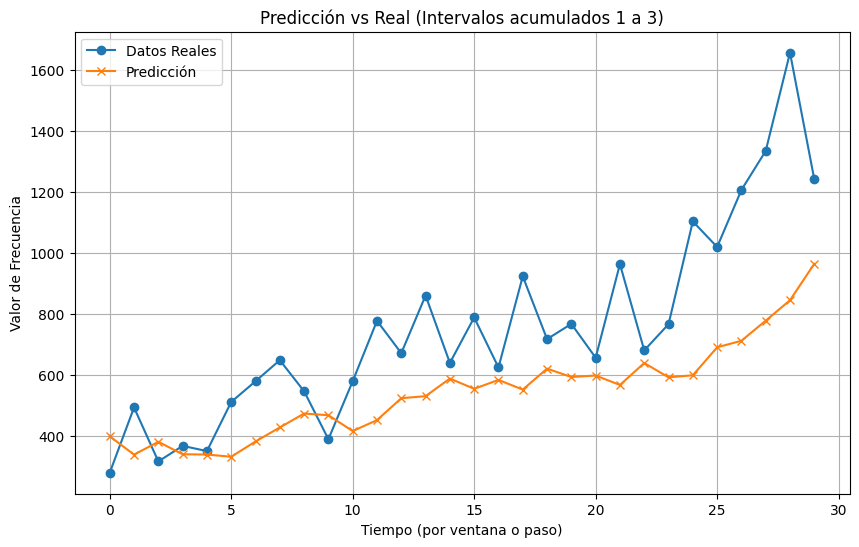

Iteración 4: Mejor época = 1, Loss = 0.0081
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 4: MAE = 95.23, MSE = 9111.69


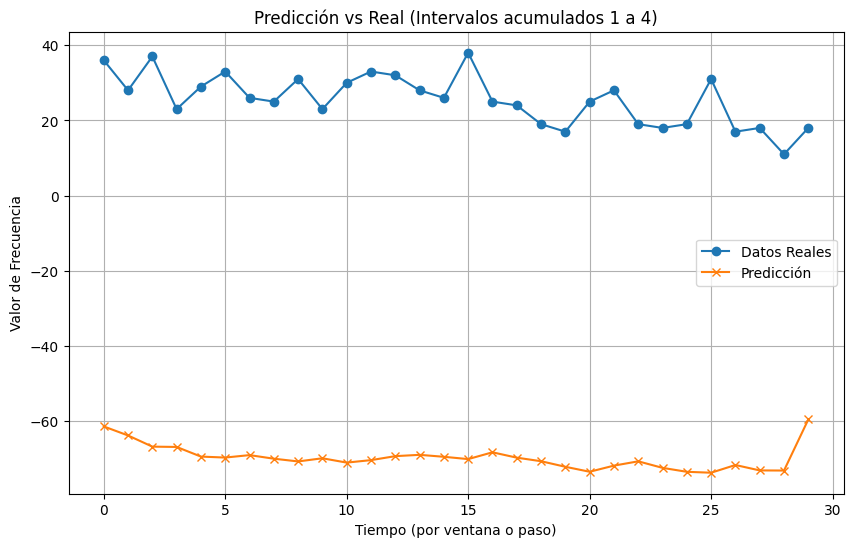

Iteración 5: Mejor época = 2, Loss = 0.0082
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 5: MAE = 77.23, MSE = 12524.93


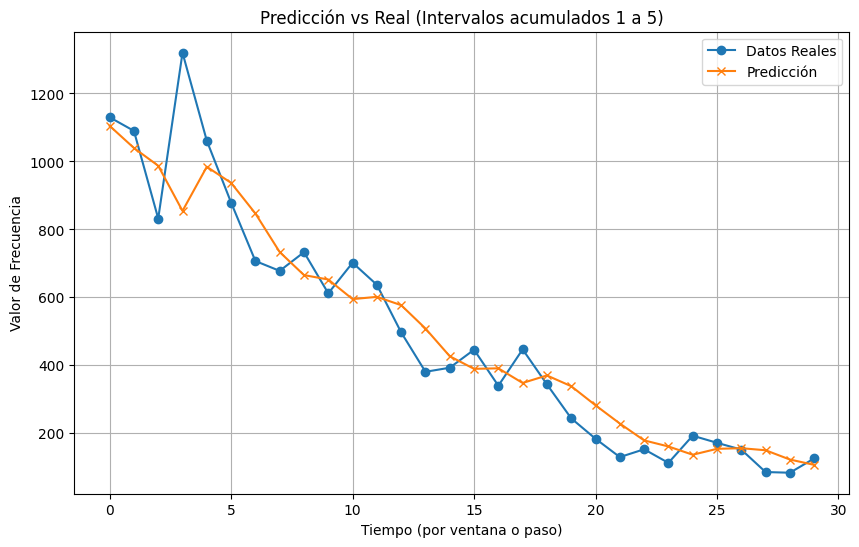

Iteración 6: Mejor época = 6, Loss = 0.0076
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Acumulando intervalos 1 a 6: MAE = 28.50, MSE = 1029.76


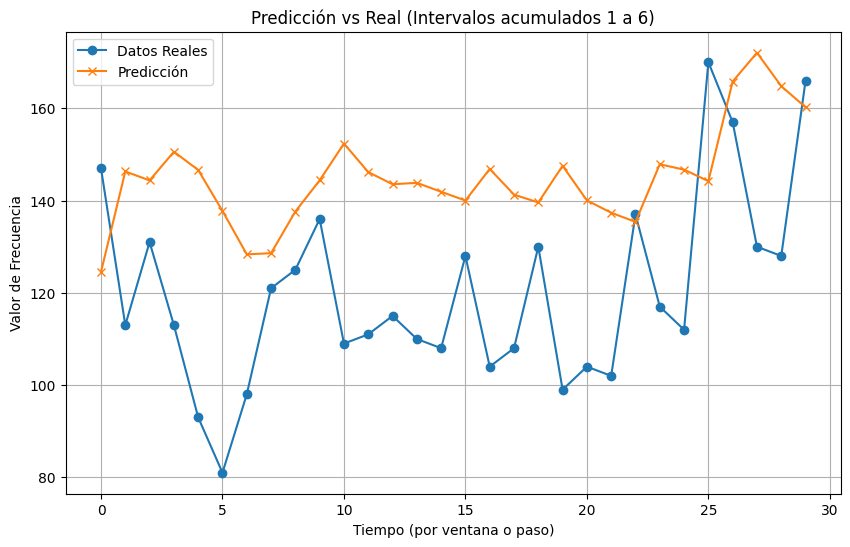

Iteración 7: Mejor época = 5, Loss = 0.0062
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Acumulando intervalos 1 a 7: MAE = 62.57, MSE = 6314.80


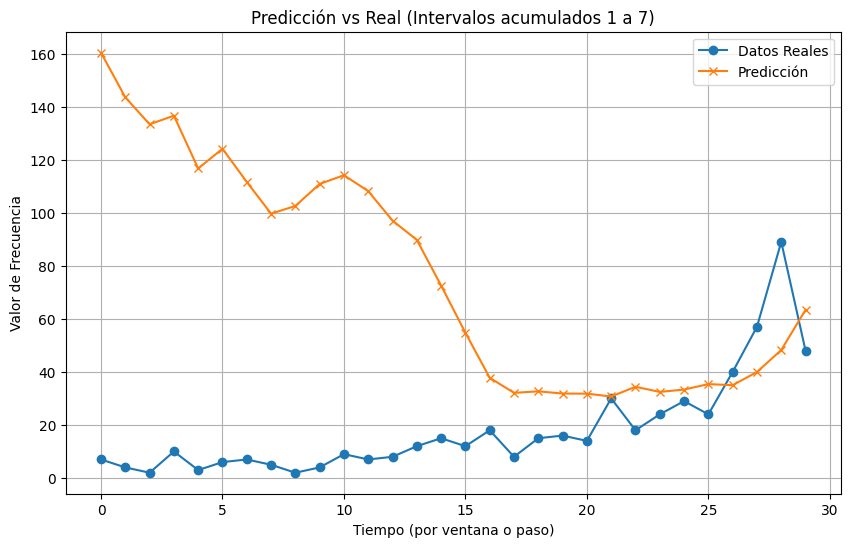

Iteración 8: Mejor época = 25, Loss = 0.0050
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 8: MAE = 15.83, MSE = 509.60


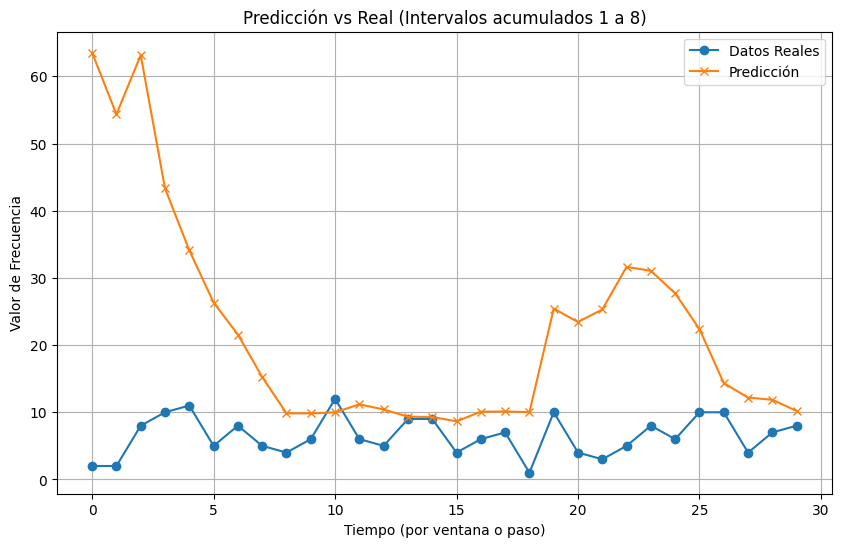


Resumen de métricas:
  Intervalos Acumulados         MAE           MSE       SMAPE
0      Intervalos 1 a 1   56.696829   6234.007453   25.475616
1      Intervalos 1 a 2   93.614615  15642.027965   20.881448
2      Intervalos 1 a 3  223.485338  83977.967087   31.388996
3      Intervalos 1 a 4   95.229710   9111.694586  200.000000
4      Intervalos 1 a 5   77.227740  12524.932425   19.757362
5      Intervalos 1 a 6   28.504750   1029.763692   22.241876
6      Intervalos 1 a 7   62.567489   6314.798755  115.557093
7      Intervalos 1 a 8   15.830141    509.600381   92.191693


In [20]:
# Parameters
WINDOW_SIZE = 7 
HORIZONTE = 30 
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es_cb],
        verbose=0
    )
    
    # Se añade logica de la función de perdida
    # 1) Encuentro la época de mínima pérdida
    loss_vals = history.history['loss']
    epochs_ran = len(loss_vals) 
    best_epoch = int(np.argmin(loss_vals)) + 1         # +1 porque los epochs comienzan en 1
    best_loss = loss_vals[best_epoch-1]
    print(f"Iteración {i+1}: Mejor época = {best_epoch}, Loss = {best_loss:.4f}")

    # 2) Grafico la curva de entrenamiento y marco la mejor época
    plt.figure(figsize=(8,5))
    ax = plt.gca()  # obtenemos el eje actual
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
    plt.plot(range(1, epochs_ran+1), loss_vals, marker='o', label='Training loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
    plt.title(f"Pérdida durante el entrenamiento\nIntervalos 1 a {i+1}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 3) Guardo la figura en la carpeta
    plot_path = os.path.join(loss_folder, f"7_30_loss_intervalos_1_{i+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close() 

    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_3/lstm_7_30.csv', index=False)

### Train for windows size = 14

Iteración 1: Mejor época = 16, Loss = 0.0008
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Acumulando intervalos 1 a 1: MAE = 89.54, MSE = 11807.27


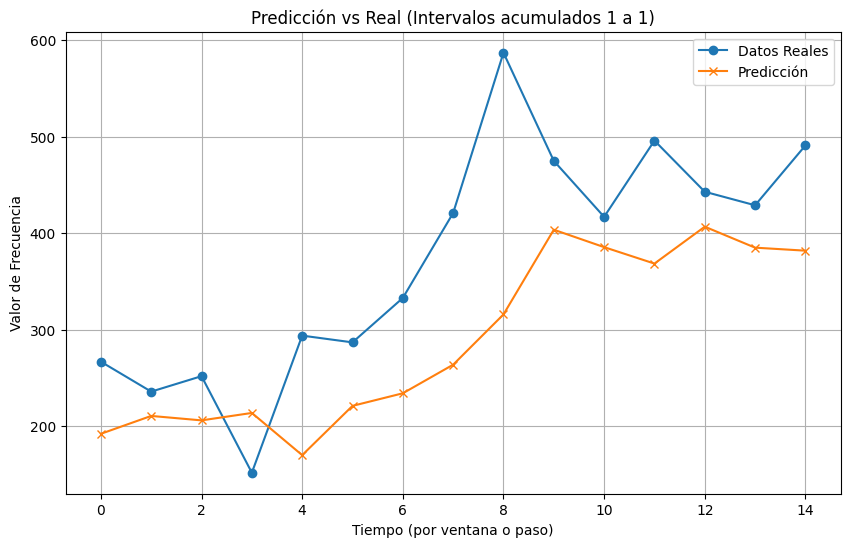

Iteración 2: Mejor época = 11, Loss = 0.0174
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 2: MAE = 116.69, MSE = 23067.33


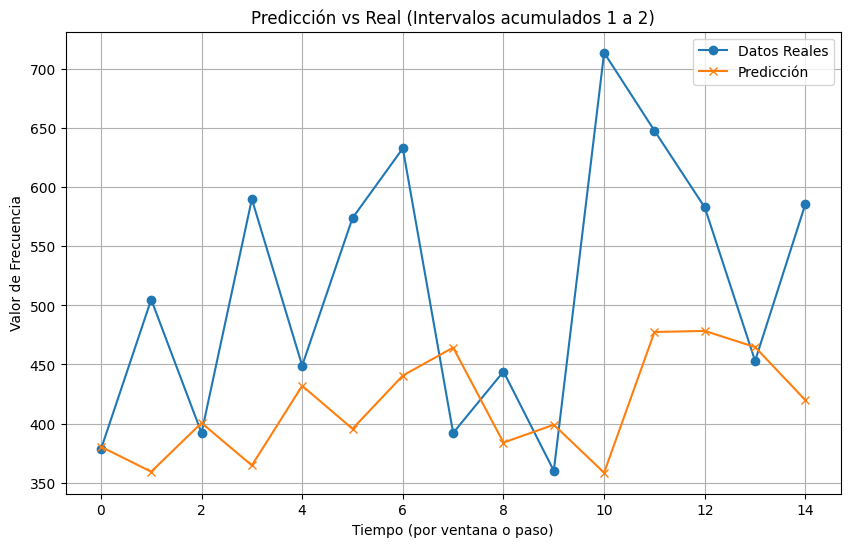

Iteración 3: Mejor época = 6, Loss = 0.0063
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Acumulando intervalos 1 a 3: MAE = 302.94, MSE = 136429.85


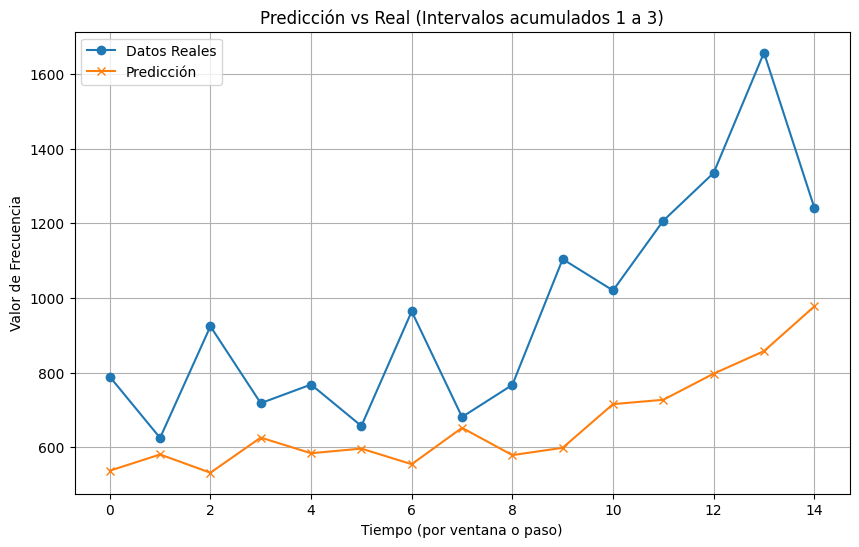

Iteración 4: Mejor época = 16, Loss = 0.0092
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 4: MAE = 196.25, MSE = 38603.17


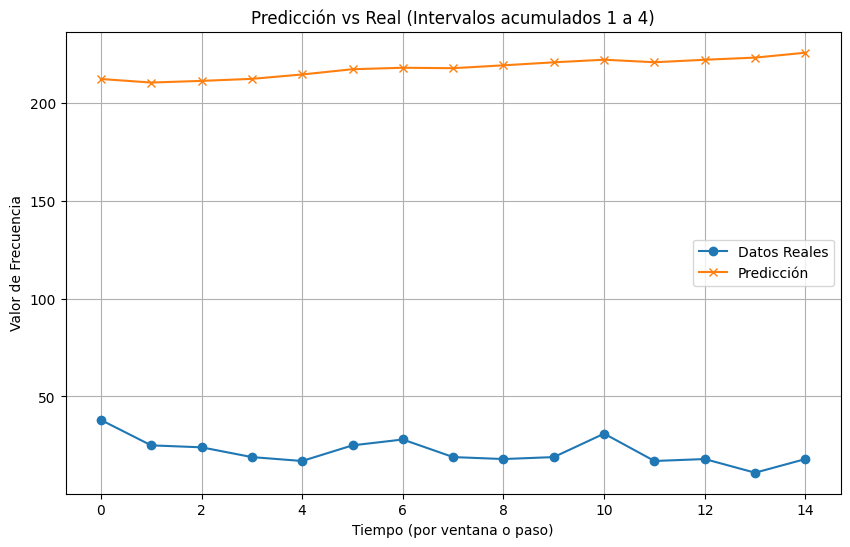

Iteración 5: Mejor época = 5, Loss = 0.0082
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 5: MAE = 48.37, MSE = 3569.73


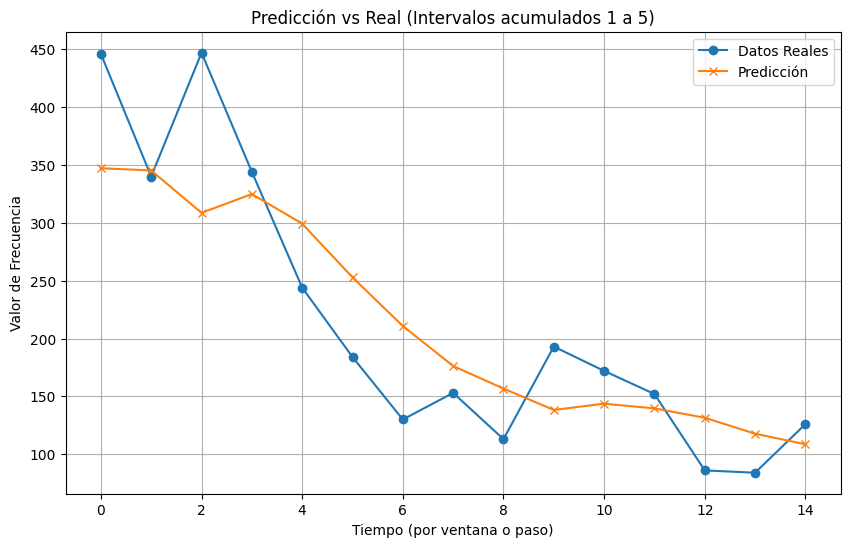

Iteración 6: Mejor época = 14, Loss = 0.0076
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Acumulando intervalos 1 a 6: MAE = 32.78, MSE = 1504.57


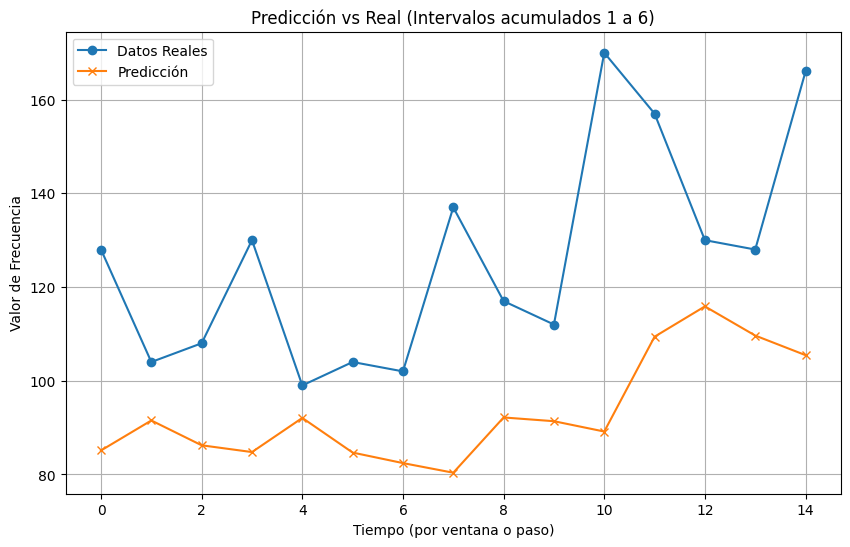

Iteración 7: Mejor época = 20, Loss = 0.0061
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Acumulando intervalos 1 a 7: MAE = 42.88, MSE = 2657.02


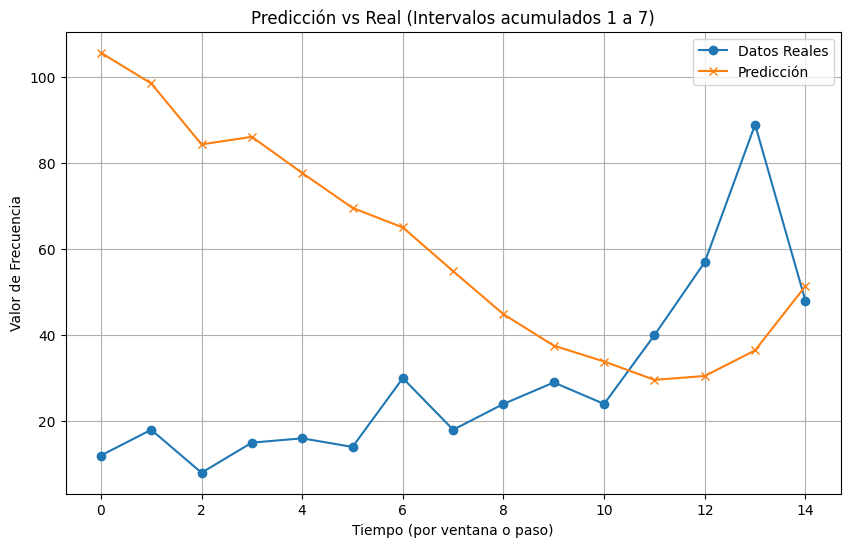

Iteración 8: Mejor época = 13, Loss = 0.0049
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 8: MAE = 60.04, MSE = 3649.36


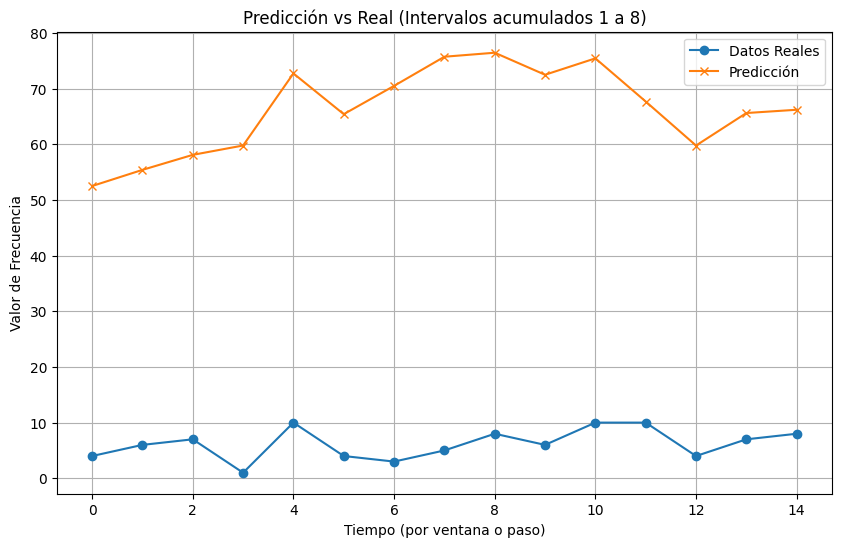


Resumen de métricas:
  Intervalos Acumulados         MAE            MSE       SMAPE
0      Intervalos 1 a 1   89.544804   11807.270514   27.689189
1      Intervalos 1 a 2  116.685439   23067.331149   23.596334
2      Intervalos 1 a 3  302.937061  136429.846753   34.540918
3      Intervalos 1 a 4  196.249671   38603.165254  163.823293
4      Intervalos 1 a 5   48.368392    3569.730079   24.281961
5      Intervalos 1 a 6   32.781848    1504.567313   28.819323
6      Intervalos 1 a 7   42.884850    2657.015115   89.648013
7      Intervalos 1 a 8   60.035306    3649.356443  166.455002


In [21]:
# Parameters
WINDOW_SIZE = 14 
HORIZONTE = 15 
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es_cb],
        verbose=0
    )
    
    # Se añade logica de la función de perdida
    # 1) Encuentro la época de mínima pérdida
    loss_vals = history.history['loss']
    epochs_ran = len(loss_vals) 
    best_epoch = int(np.argmin(loss_vals)) + 1         # +1 porque los epochs comienzan en 1
    best_loss = loss_vals[best_epoch-1]
    print(f"Iteración {i+1}: Mejor época = {best_epoch}, Loss = {best_loss:.4f}")

    # 2) Grafico la curva de entrenamiento y marco la mejor época
    plt.figure(figsize=(8,5))
    ax = plt.gca()  # obtenemos el eje actual
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
    plt.plot(range(1, epochs_ran+1), loss_vals, marker='o', label='Training loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
    plt.title(f"Pérdida durante el entrenamiento\nIntervalos 1 a {i+1}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 3) Guardo la figura en la carpeta
    plot_path = os.path.join(loss_folder, f"14_15_loss_intervalos_1_{i+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close() 

    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_3/lstm_14_15.csv', index=False)

Iteración 1: Mejor época = 9, Loss = 0.0002
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 1: MAE = 71.83, MSE = 8679.10


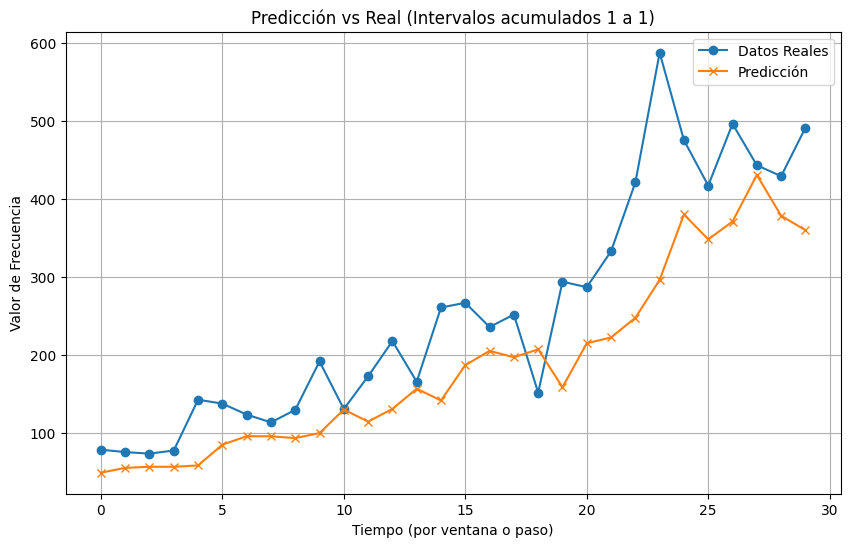

Iteración 2: Mejor época = 37, Loss = 0.0176
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Acumulando intervalos 1 a 2: MAE = 93.12, MSE = 15373.47


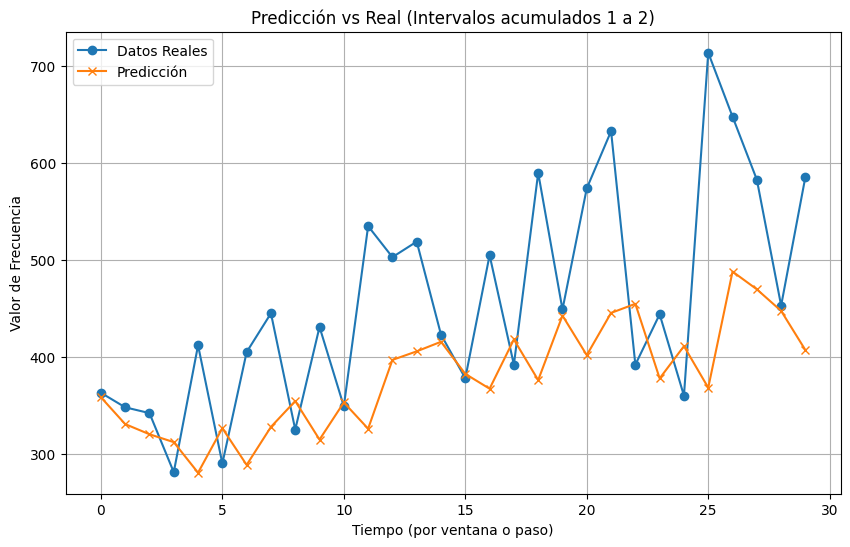

Iteración 3: Mejor época = 7, Loss = 0.0049
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Acumulando intervalos 1 a 3: MAE = 230.26, MSE = 89370.04


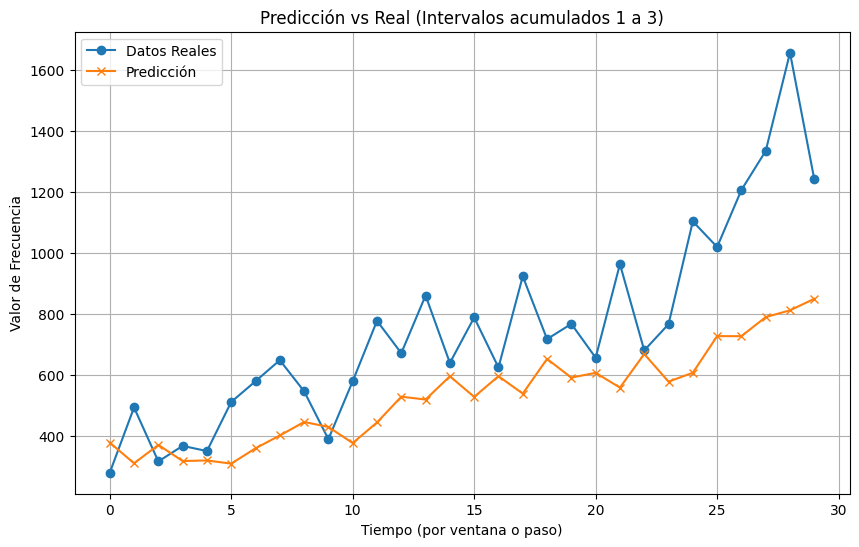

Iteración 4: Mejor época = 15, Loss = 0.0065
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Acumulando intervalos 1 a 4: MAE = 6.93, MSE = 68.95


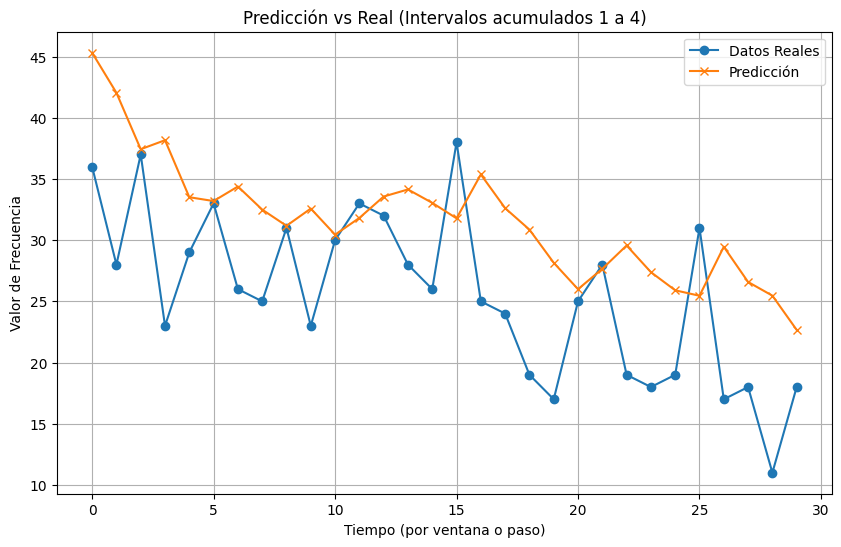

Iteración 5: Mejor época = 17, Loss = 0.0070
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Acumulando intervalos 1 a 5: MAE = 93.75, MSE = 21750.85


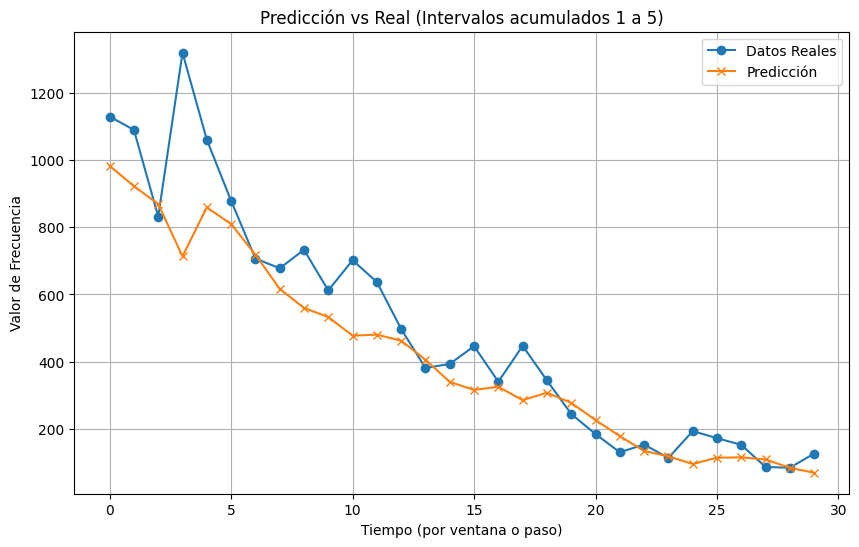

Iteración 6: Mejor época = 23, Loss = 0.0054
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 6: MAE = 16.54, MSE = 561.55


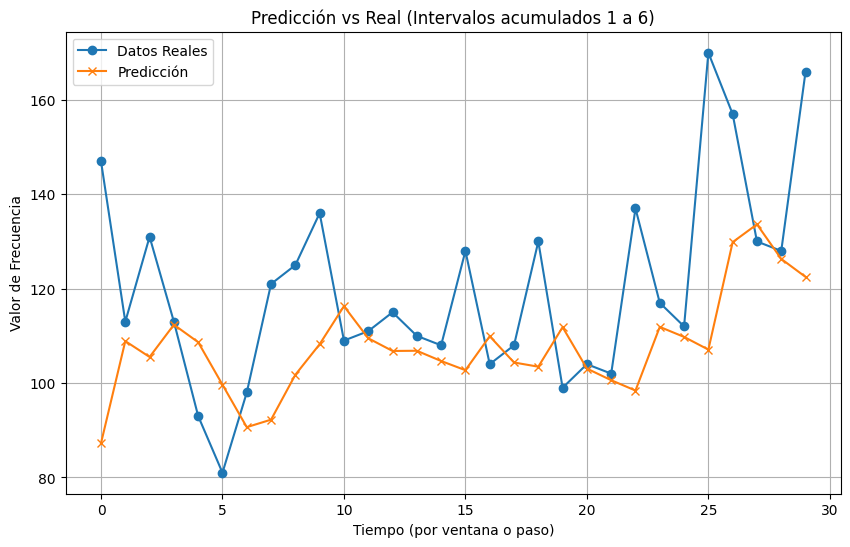

Iteración 7: Mejor época = 15, Loss = 0.0052
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 7: MAE = 17.64, MSE = 605.66


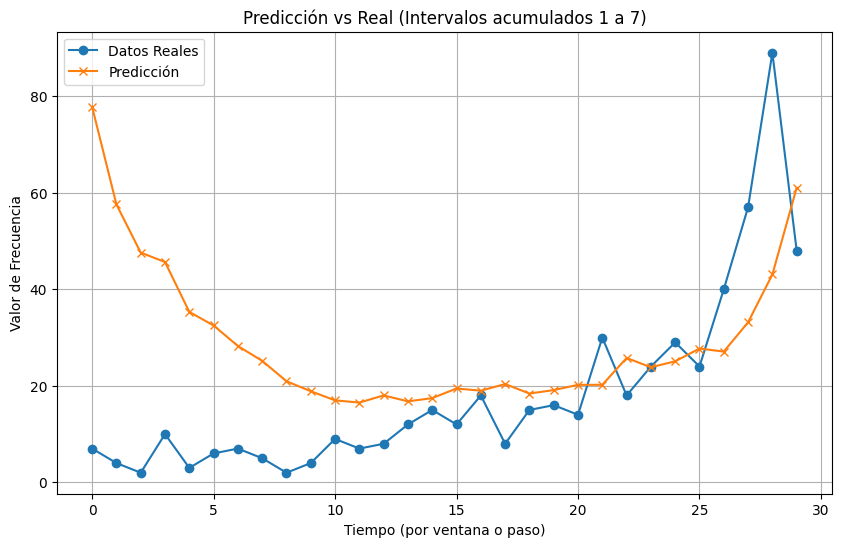

Iteración 8: Mejor época = 20, Loss = 0.0047
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Acumulando intervalos 1 a 8: MAE = 2.90, MSE = 12.15


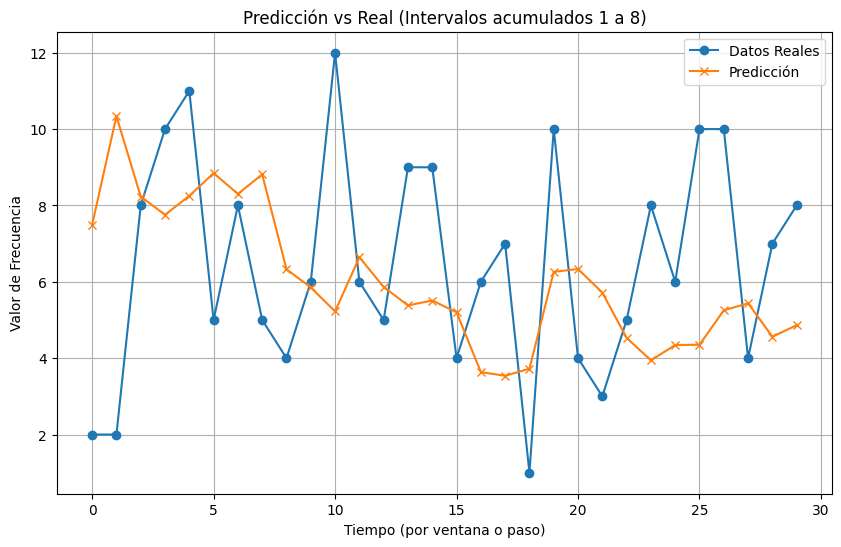


Resumen de métricas:
  Intervalos Acumulados         MAE           MSE      SMAPE
0      Intervalos 1 a 1   71.825115   8679.103364  34.008639
1      Intervalos 1 a 2   93.123278  15373.469379  20.885737
2      Intervalos 1 a 3  230.261168  89370.039442  32.865282
3      Intervalos 1 a 4    6.926193     68.953031  26.184824
4      Intervalos 1 a 5   93.751540  21750.850386  22.151949
5      Intervalos 1 a 6   16.539713    561.548191  13.938009
6      Intervalos 1 a 7   17.635171    605.662059  75.996684
7      Intervalos 1 a 8    2.900450     12.148698  48.487560


In [22]:
# Parameters
WINDOW_SIZE = 14 
HORIZONTE = 30 
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es_cb],
        verbose=0
    )
    
    # Se añade logica de la función de perdida
    # 1) Encuentro la época de mínima pérdida
    loss_vals = history.history['loss']
    epochs_ran = len(loss_vals) 
    best_epoch = int(np.argmin(loss_vals)) + 1         # +1 porque los epochs comienzan en 1
    best_loss = loss_vals[best_epoch-1]
    print(f"Iteración {i+1}: Mejor época = {best_epoch}, Loss = {best_loss:.4f}")

    # 2) Grafico la curva de entrenamiento y marco la mejor época
    plt.figure(figsize=(8,5))
    ax = plt.gca()  # obtenemos el eje actual
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
    plt.plot(range(1, epochs_ran+1), loss_vals, marker='o', label='Training loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
    plt.title(f"Pérdida durante el entrenamiento\nIntervalos 1 a {i+1}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 3) Guardo la figura en la carpeta
    plot_path = os.path.join(loss_folder, f"14_30_loss_intervalos_1_{i+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close() 

    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_3/lstm_14_30.csv', index=False)

### Train for windows size = 21


Iteración 1: Mejor época = 7, Loss = 0.0009
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Acumulando intervalos 1 a 1: MAE = 95.51, MSE = 14117.68


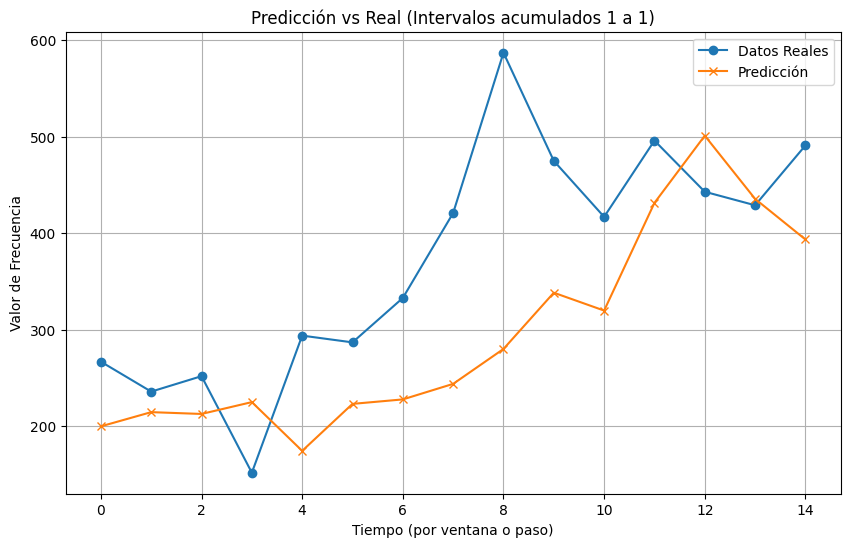

Iteración 2: Mejor época = 7, Loss = 0.0194
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 2: MAE = 119.78, MSE = 24269.13


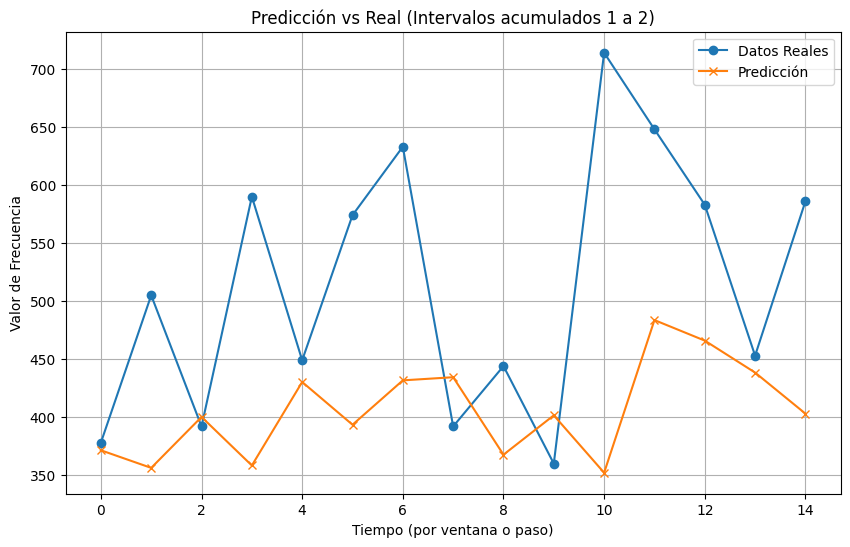

Iteración 3: Mejor época = 7, Loss = 0.0061
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Acumulando intervalos 1 a 3: MAE = 344.37, MSE = 172042.41


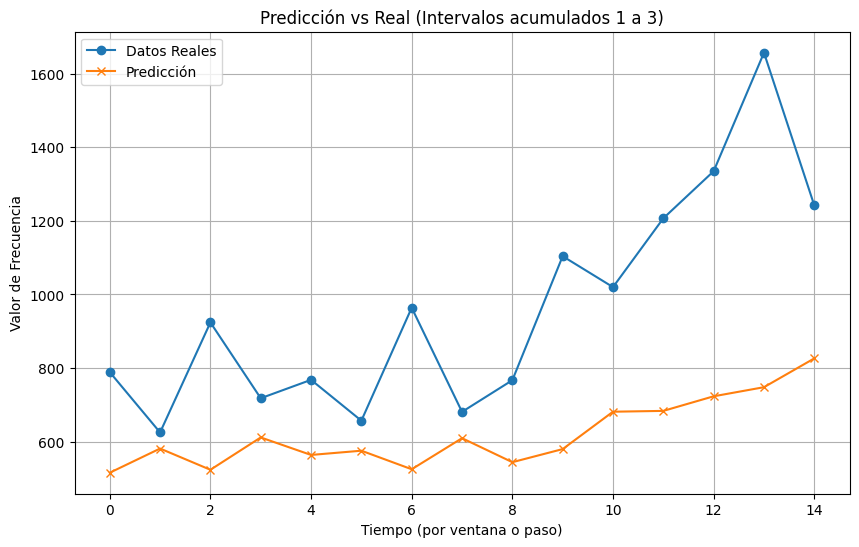

Iteración 4: Mejor época = 7, Loss = 0.0098
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 4: MAE = 119.47, MSE = 14311.08


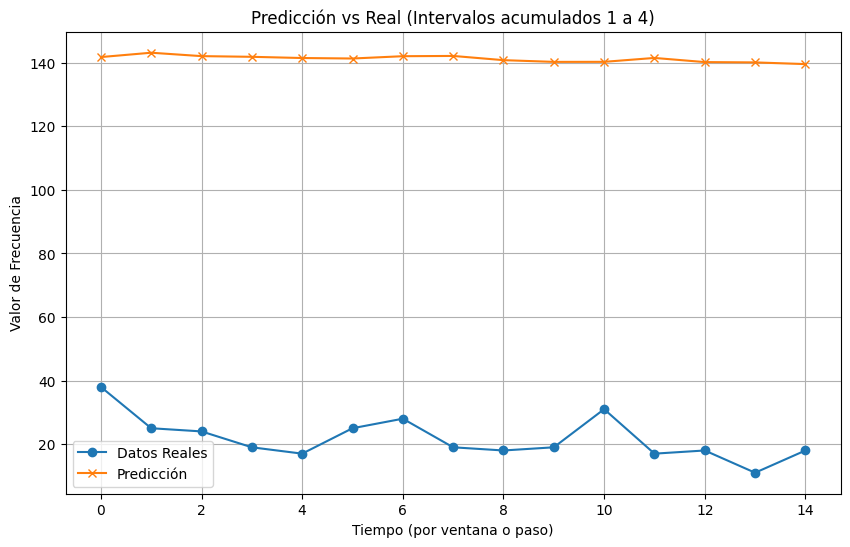

Iteración 5: Mejor época = 6, Loss = 0.0086
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Acumulando intervalos 1 a 5: MAE = 75.02, MSE = 6777.35


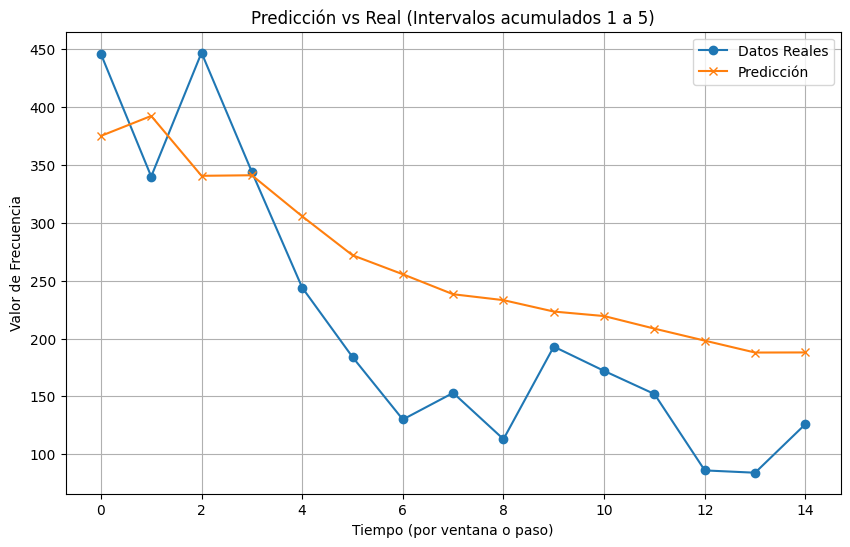

Iteración 6: Mejor época = 2, Loss = 0.0089
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 6: MAE = 37.21, MSE = 1686.01


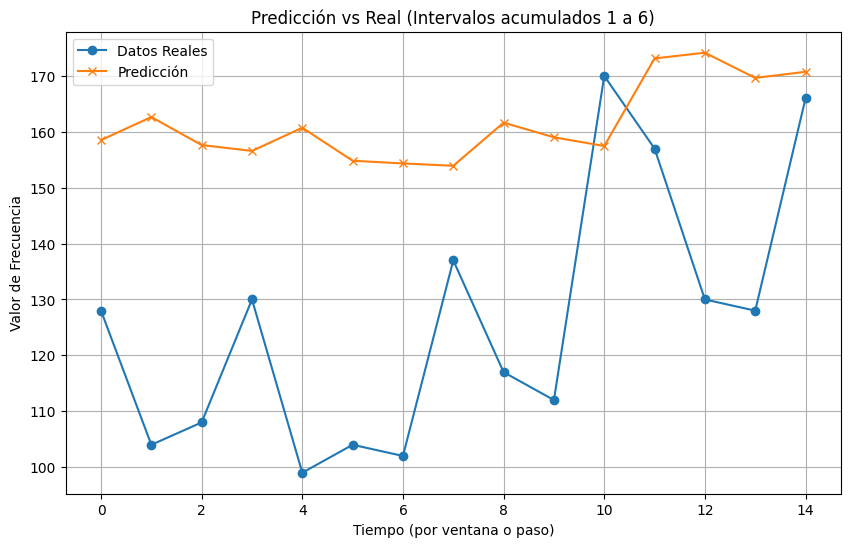

Iteración 7: Mejor época = 16, Loss = 0.0055
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 7: MAE = 23.98, MSE = 875.33


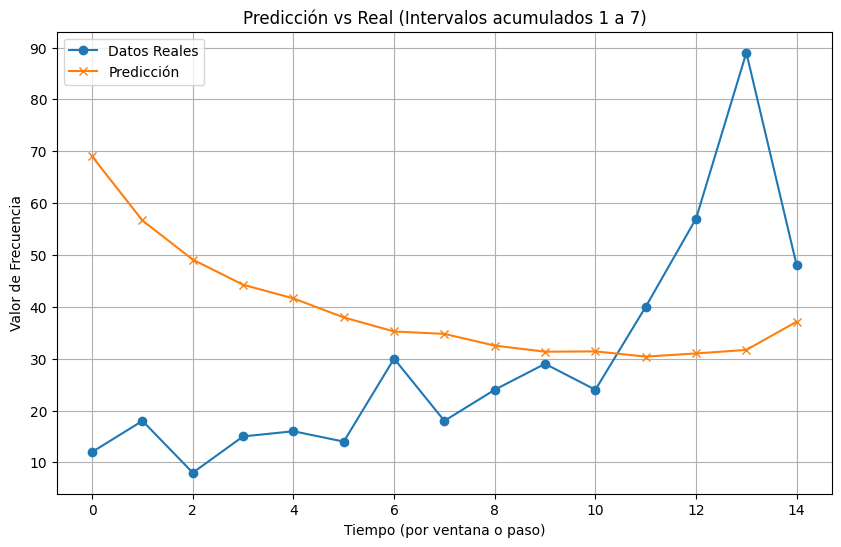

Iteración 8: Mejor época = 8, Loss = 0.0047
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Acumulando intervalos 1 a 8: MAE = 12.44, MSE = 164.53


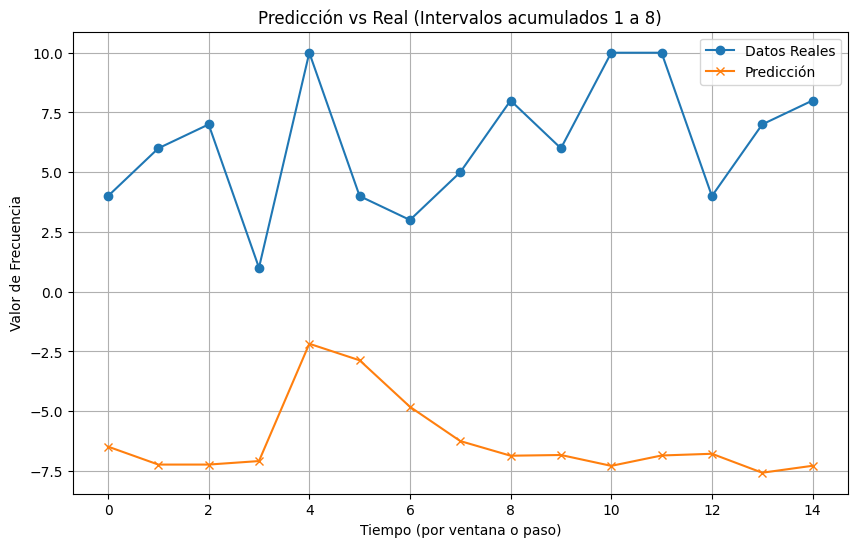


Resumen de métricas:
  Intervalos Acumulados         MAE            MSE       SMAPE
0      Intervalos 1 a 1   95.514283   14117.683989   29.385827
1      Intervalos 1 a 2  119.781244   24269.133324   24.405651
2      Intervalos 1 a 3  344.370850  172042.407773   40.071909
3      Intervalos 1 a 4  119.465167   14311.075617  147.087892
4      Intervalos 1 a 5   75.019804    6777.352465   37.567940
5      Intervalos 1 a 6   37.206405    1686.006144   26.967331
6      Intervalos 1 a 7   23.975167     875.331314   67.950434
7      Intervalos 1 a 8   12.444538     164.527676  200.000000


In [23]:
# Parameters
WINDOW_SIZE = 21 
HORIZONTE = 15 
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es_cb],
        verbose=0
    )
    
    # Se añade logica de la función de perdida
    # 1) Encuentro la época de mínima pérdida
    loss_vals = history.history['loss']
    epochs_ran = len(loss_vals) 
    best_epoch = int(np.argmin(loss_vals)) + 1         # +1 porque los epochs comienzan en 1
    best_loss = loss_vals[best_epoch-1]
    print(f"Iteración {i+1}: Mejor época = {best_epoch}, Loss = {best_loss:.4f}")

    # 2) Grafico la curva de entrenamiento y marco la mejor época
    plt.figure(figsize=(8,5))
    ax = plt.gca()  # obtenemos el eje actual
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
    plt.plot(range(1, epochs_ran+1), loss_vals, marker='o', label='Training loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
    plt.title(f"Pérdida durante el entrenamiento\nIntervalos 1 a {i+1}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 3) Guardo la figura en la carpeta
    plot_path = os.path.join(loss_folder, f"21_15_loss_intervalos_1_{i+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close() 

    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_3/lstm_21_15.csv', index=False)

Iteración 1: Mejor época = 12, Loss = 0.0002
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Acumulando intervalos 1 a 1: MAE = 66.06, MSE = 8274.90


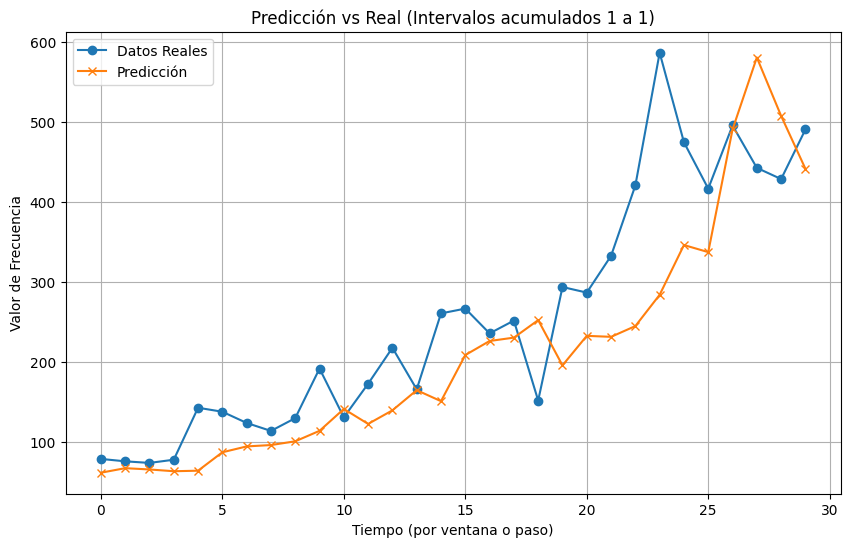

Iteración 2: Mejor época = 6, Loss = 0.0179
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Acumulando intervalos 1 a 2: MAE = 94.89, MSE = 14719.98


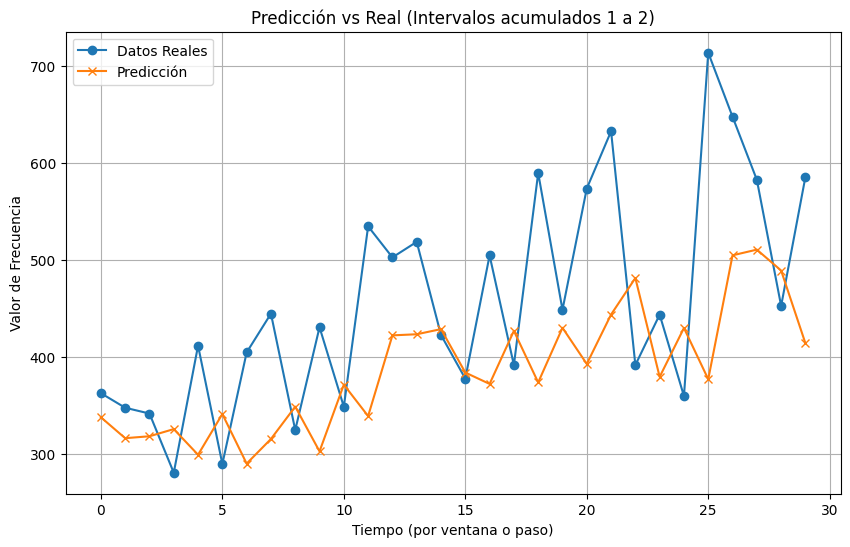

Iteración 3: Mejor época = 12, Loss = 0.0041
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Acumulando intervalos 1 a 3: MAE = 230.58, MSE = 85917.75


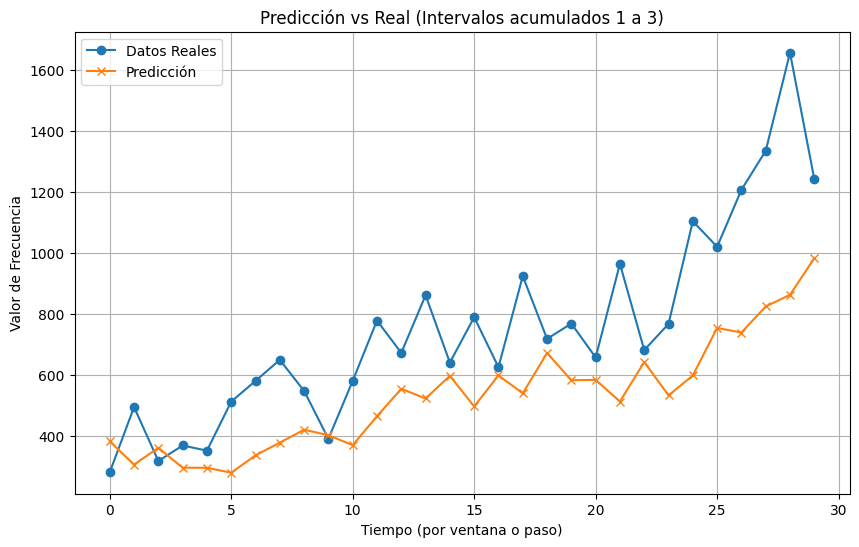

Iteración 4: Mejor época = 4, Loss = 0.0061
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Acumulando intervalos 1 a 4: MAE = 41.23, MSE = 1732.53


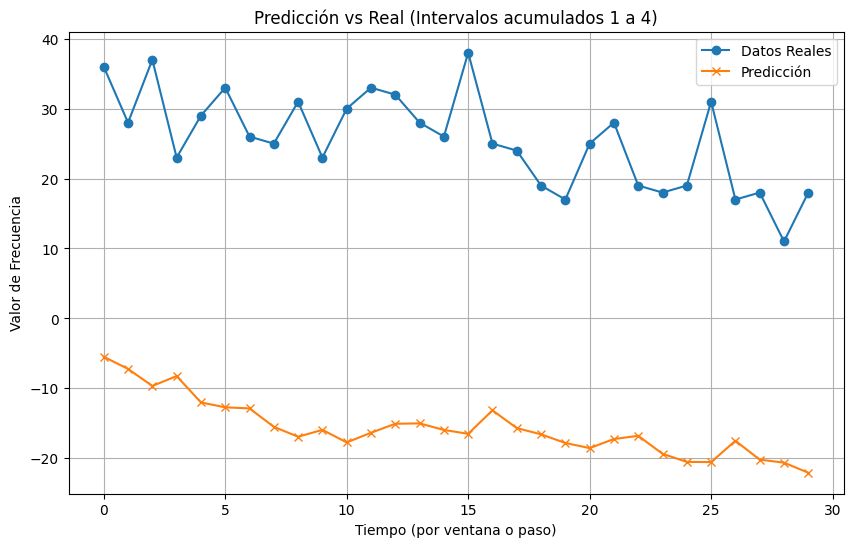

Iteración 5: Mejor época = 1, Loss = 0.0065
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 5: MAE = 90.77, MSE = 19727.47


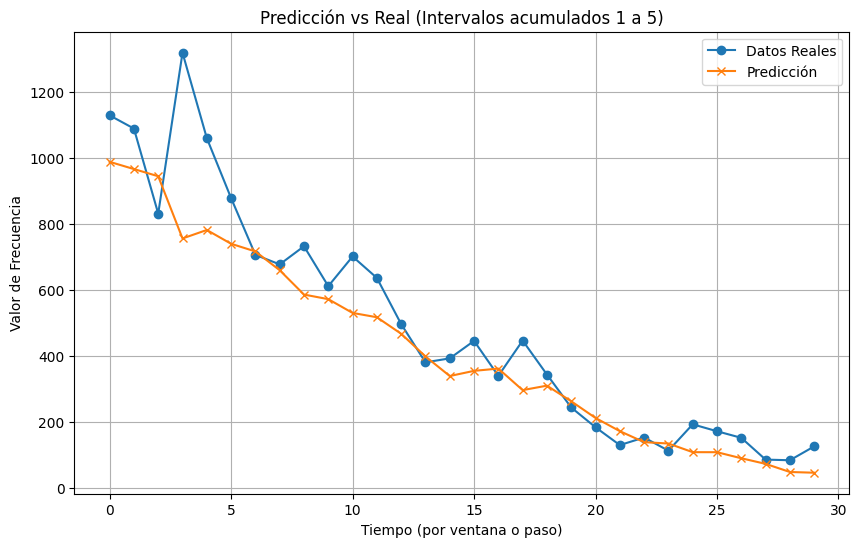

Iteración 6: Mejor época = 11, Loss = 0.0053
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Acumulando intervalos 1 a 6: MAE = 22.30, MSE = 820.74


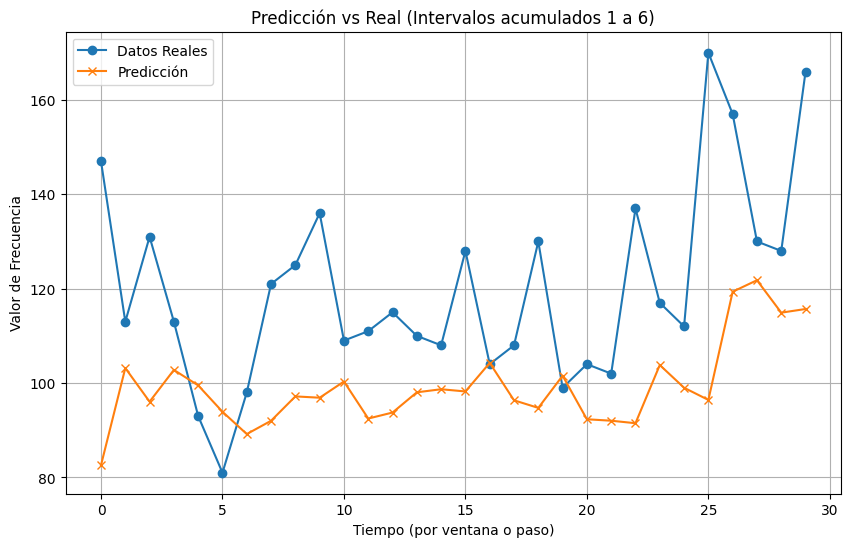

Iteración 7: Mejor época = 3, Loss = 0.0047
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Acumulando intervalos 1 a 7: MAE = 35.97, MSE = 2685.37


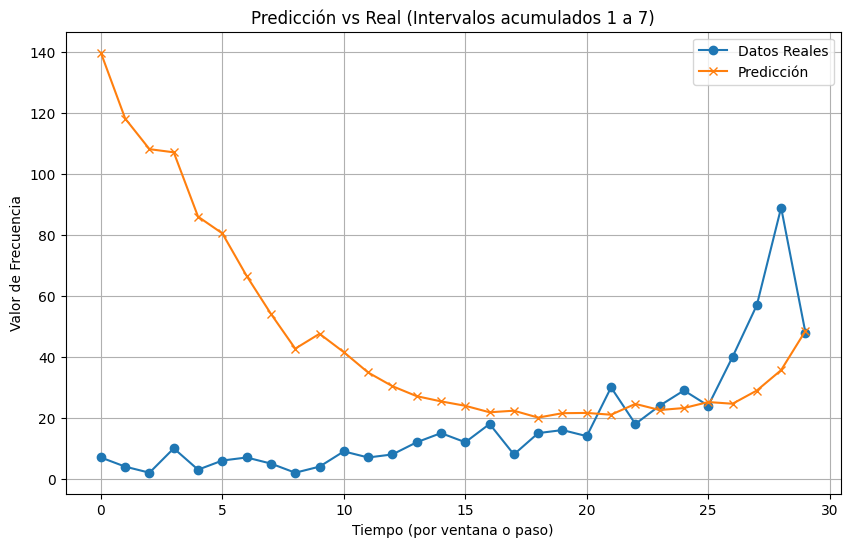

Iteración 8: Mejor época = 8, Loss = 0.0048
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 8: MAE = 52.06, MSE = 2806.83


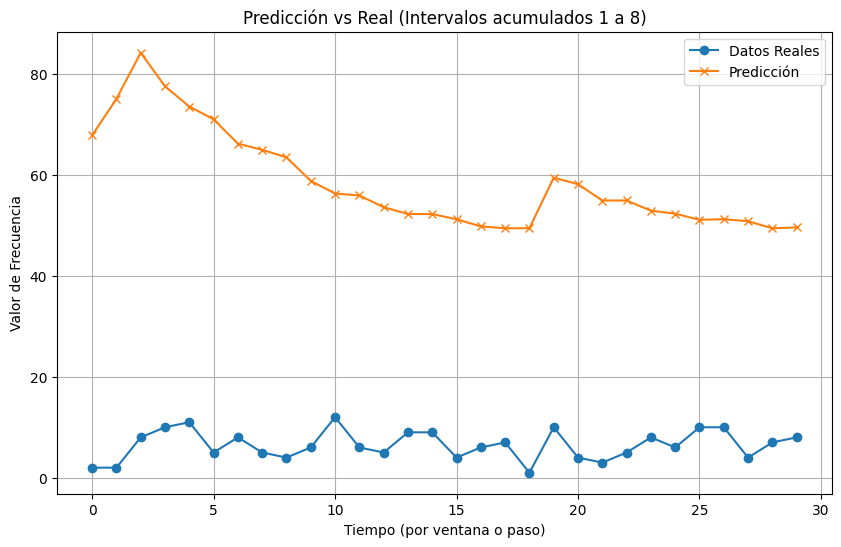


Resumen de métricas:
  Intervalos Acumulados         MAE           MSE       SMAPE
0      Intervalos 1 a 1   66.064585   8274.901314   28.737082
1      Intervalos 1 a 2   94.885232  14719.977042   21.429776
2      Intervalos 1 a 3  230.581829  85917.754729   33.940061
3      Intervalos 1 a 4   41.232441   1732.526085  200.000000
4      Intervalos 1 a 5   90.770721  19727.467607   23.937988
5      Intervalos 1 a 6   22.297879    820.739583   19.442174
6      Intervalos 1 a 7   35.965920   2685.373172   95.069613
7      Intervalos 1 a 8   52.056837   2806.827373  159.993652


: 

In [ ]:
# Parameters
WINDOW_SIZE = 21 
HORIZONTE = 30
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es_cb],
        verbose=0
    )
    
    # Se añade logica de la función de perdida
    # 1) Encuentro la época de mínima pérdida
    loss_vals = history.history['loss']
    epochs_ran = len(loss_vals) 
    best_epoch = int(np.argmin(loss_vals)) + 1         # +1 porque los epochs comienzan en 1
    best_loss = loss_vals[best_epoch-1]
    print(f"Iteración {i+1}: Mejor época = {best_epoch}, Loss = {best_loss:.4f}")

    # 2) Grafico la curva de entrenamiento y marco la mejor época
    plt.figure(figsize=(8,5))
    ax = plt.gca()  # obtenemos el eje actual
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
    plt.plot(range(1, epochs_ran+1), loss_vals, marker='o', label='Training loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
    plt.title(f"Pérdida durante el entrenamiento\nIntervalos 1 a {i+1}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 3) Guardo la figura en la carpeta
    plot_path = os.path.join(loss_folder, f"21_30_loss_intervalos_1_{i+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close() 

    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_3/lstm_21_30.csv', index=False)

## TimesFM

In [24]:
import pandas as pd
import timesfm
import os
from huggingface_hub import login
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from dotenv import load_dotenv


load_dotenv()
hf_token = os.getenv("HUGGINGFACE_API_KEY")
# Log in with the token
login(token=hf_token)


Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 5117.50it/s]


Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 1: MAE = 161.83, MSE = 39464.28


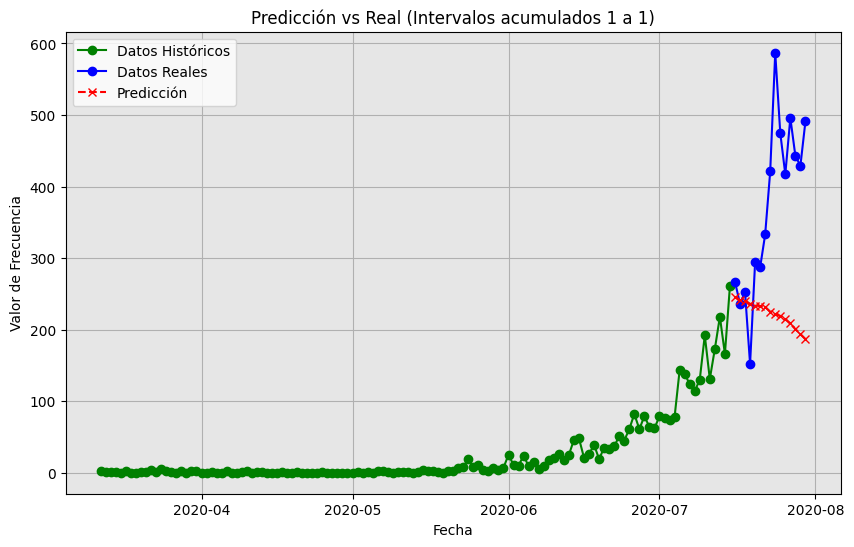

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 2: MAE = 182.36, MSE = 49539.47


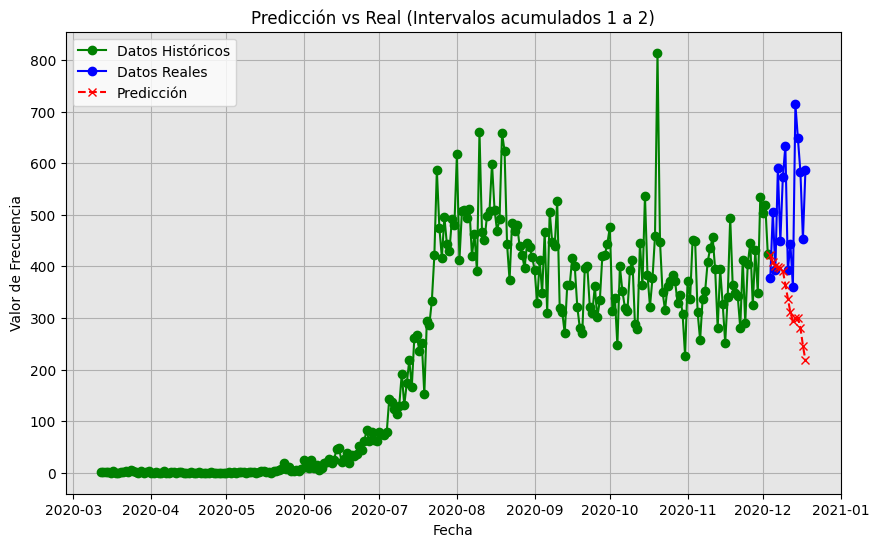

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 3: MAE = 325.83, MSE = 181618.79


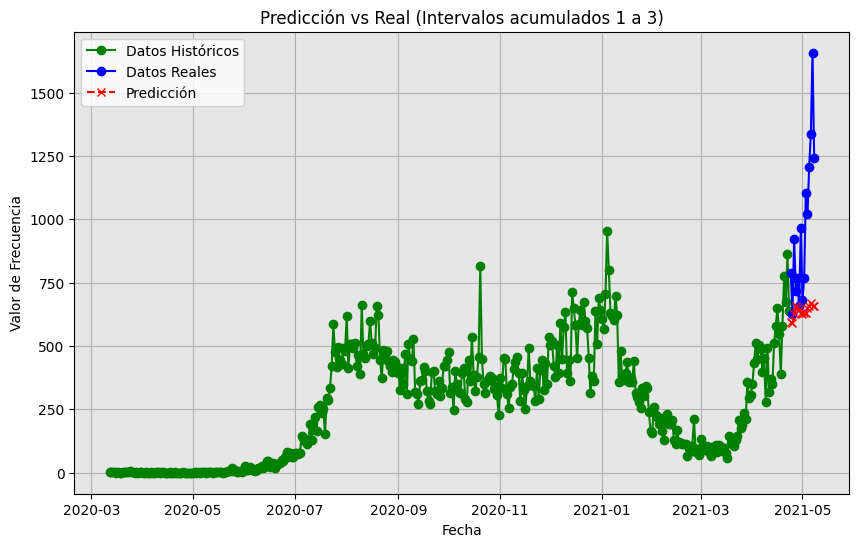

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 4: MAE = 24.57, MSE = 638.38


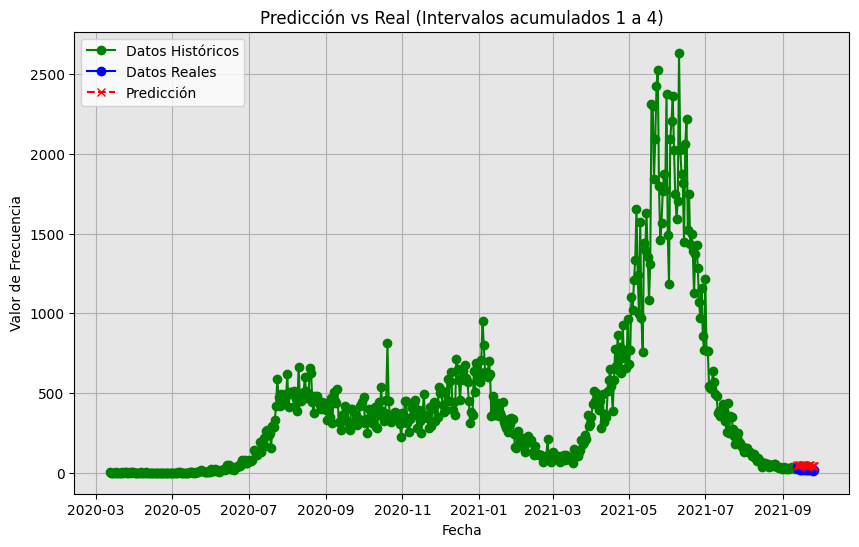

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 5: MAE = 71.05, MSE = 10091.89


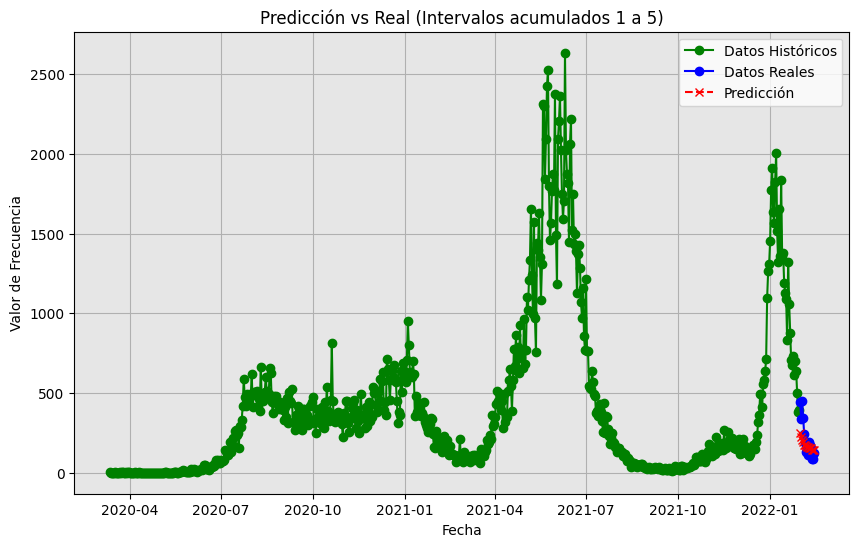

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 6: MAE = 147.89, MSE = 22724.88


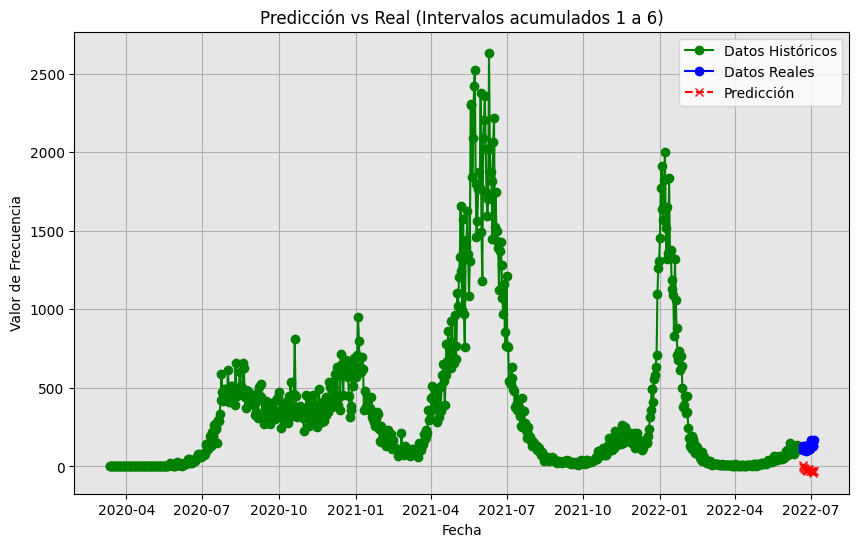

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 7: MAE = 333.50, MSE = 145953.74


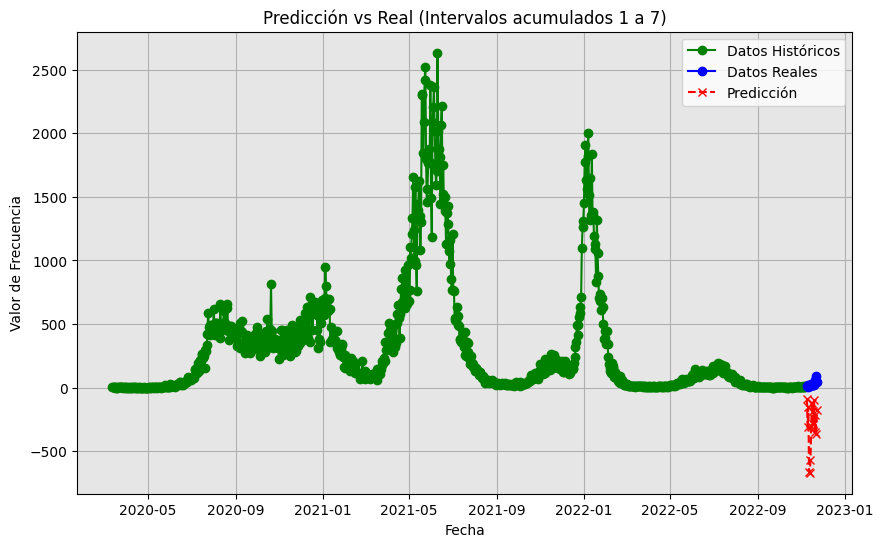

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 8: MAE = 42.47, MSE = 1823.03


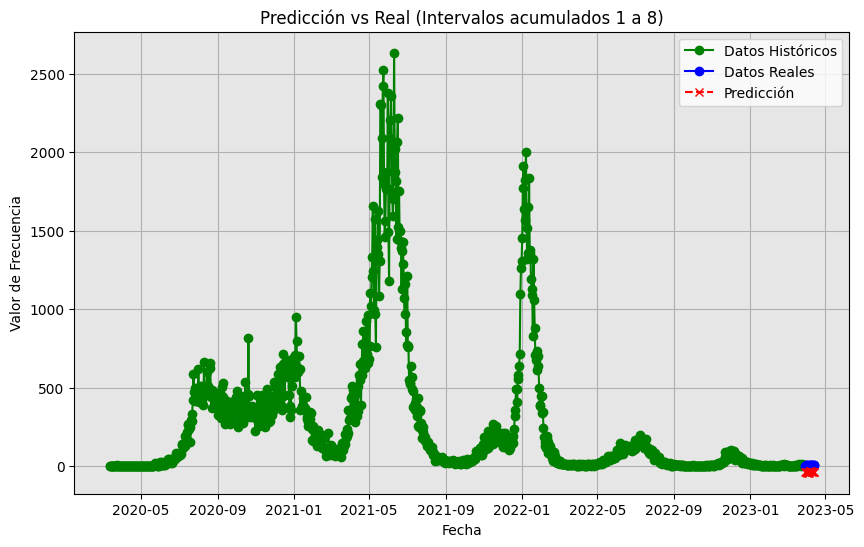


Resumen de métricas:
  Intervalos Acumulados         MAE            MSE       SMAPE
0      Intervalos 1 a 1  161.829240   39464.276278   49.960816
1      Intervalos 1 a 2  182.364549   49539.469451   41.527691
2      Intervalos 1 a 3  325.834245  181618.791114   36.126297
3      Intervalos 1 a 4   24.566073     638.379174   74.469446
4      Intervalos 1 a 5   71.046911   10091.892127   31.861175
5      Intervalos 1 a 6  147.889046   22724.882879  198.587984
6      Intervalos 1 a 7  333.495543  145953.743970  200.000000
7      Intervalos 1 a 8   42.473472    1823.031724  200.000000


In [ ]:
# Parameters
HORIZONTE = 15 # falta el 30


resultados = []

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend="gpu",
        per_core_batch_size=32,
        horizon_len=HORIZONTE,
        num_layers=50
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        version='torch',
        huggingface_repo_id="google/timesfm-2.0-500m-pytorch"),
)

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]

    df_final = df[df['Intervalo'].isin(intervalos_incluir)]
    
    series = df_final['Frecuencia'].values.reshape(-1, 1)

    # Inicializamos el escalador y escalamos la serie
    scaler = MinMaxScaler(feature_range=(0, 1))
    series_scaled = scaler.fit_transform(series)

    # Convertimos la serie escalada en un DataFrame
    df_scaled = pd.DataFrame(series_scaled, columns=['Frecuencia'])

    # Concatenamos la columna 'Fecha' con la columna escalada
    df_concatenado = pd.concat([df_final[['Fecha']].reset_index(drop=True), df_scaled], axis=1)

    df_train = df_concatenado.iloc[:-HORIZONTE].copy()
    df_test = df_concatenado.iloc[-HORIZONTE:].copy()

    # df_train = df_final.iloc[:-HORIZONTE].copy()
    # df_test = df_final.iloc[-HORIZONTE:].copy()

    # Preparing the data for training

    data_hist = df_train[['Fecha', 'Frecuencia']].rename(columns={
        'Fecha': 'ds',
        'Frecuencia': 'sales'
    })
    data_hist["unique_id"] = "series_1"

    forecast_df = tfm.forecast_on_df(
        inputs=data_hist,
        freq='D',
        forecast_context_len= len(data_hist),
        value_name='sales',
        num_jobs=-1)
    
    # 6. Alinear fechas y calcular métricas

    y_true = df_test['Frecuencia']
    y_pred = forecast_df['timesfm']
    
    y_pred = scaler.inverse_transform(y_pred.values.reshape(-1, 1))
    y_true = scaler.inverse_transform(y_true.values.reshape(-1, 1))


    # Calculamos las métricas
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    smape_value = smape(y_true, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos históricos, datos reales (test) y predicción sobre el intervalo completo
    fig, ax = plt.subplots(figsize=(10, 6))
    # Cambiar el color de fondo del eje a un gris suave
    ax.set_facecolor('#e6e6e6')  # Puedes ajustar el código hexadecimal para obtener el gris deseado

    # Graficar datos históricos (entrenamiento)
    # Aquí se vuelven a invertir las escalas para graficar los valores reales
    historico = scaler.inverse_transform(df_train['Frecuencia'].values.reshape(-1, 1))
    ax.plot(df_train['Fecha'], historico, label="Datos Históricos", marker='o', color='green')

    # Graficar datos reales del test (último intervalo)
    ax.plot(df_test['Fecha'], y_true, label="Datos Reales", marker='o', color='blue')

    # Graficar la predicción
    ax.plot(df_test['Fecha'], y_pred, label="Predicción", marker='x', linestyle='--', color='red')

    # Etiquetas y detalles de la gráfica
    ax.set_title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Valor de Frecuencia")
    ax.legend()
    ax.grid(True)

    plt.show()



df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_2/timesfm_15.csv', index=False)


Fetching 5 files: 100%|██████████| 5/5 [00:00<?, ?it/s]


Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 1: MAE = 198.98, MSE = 63915.79


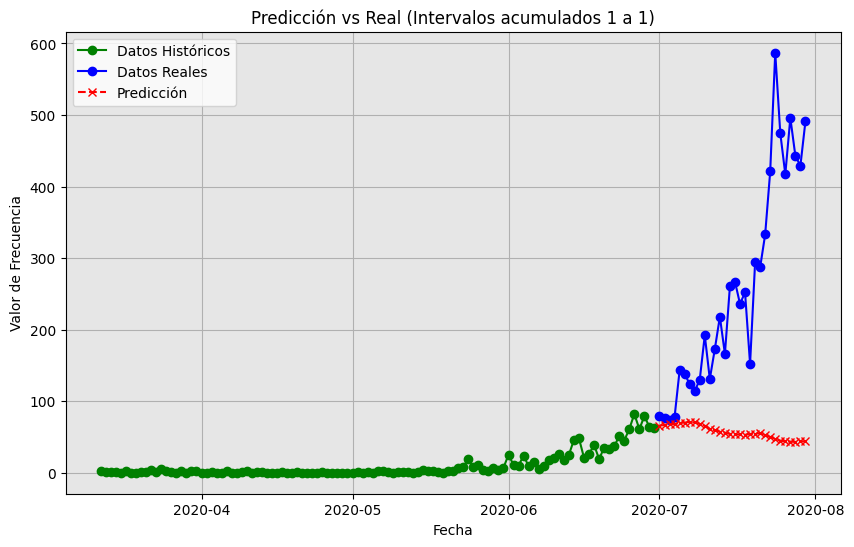

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 2: MAE = 187.61, MSE = 54042.86


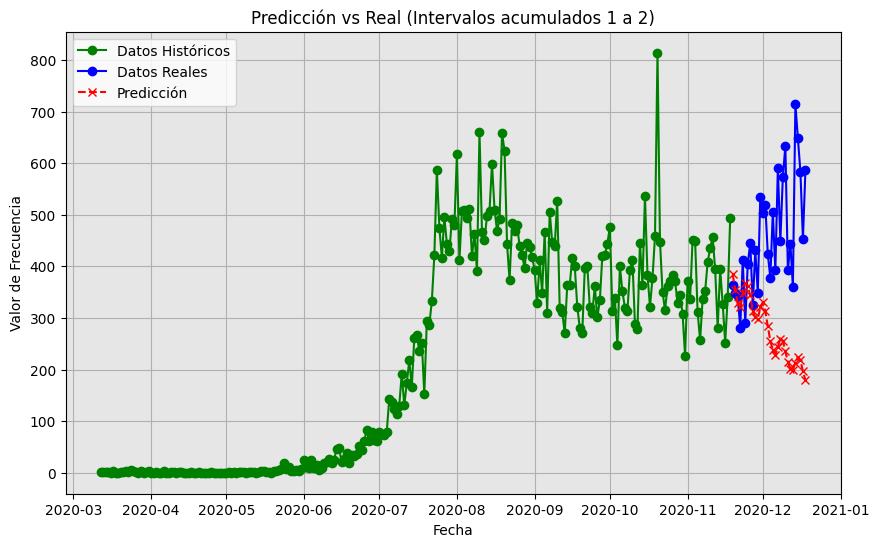

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 3: MAE = 316.34, MSE = 172432.14


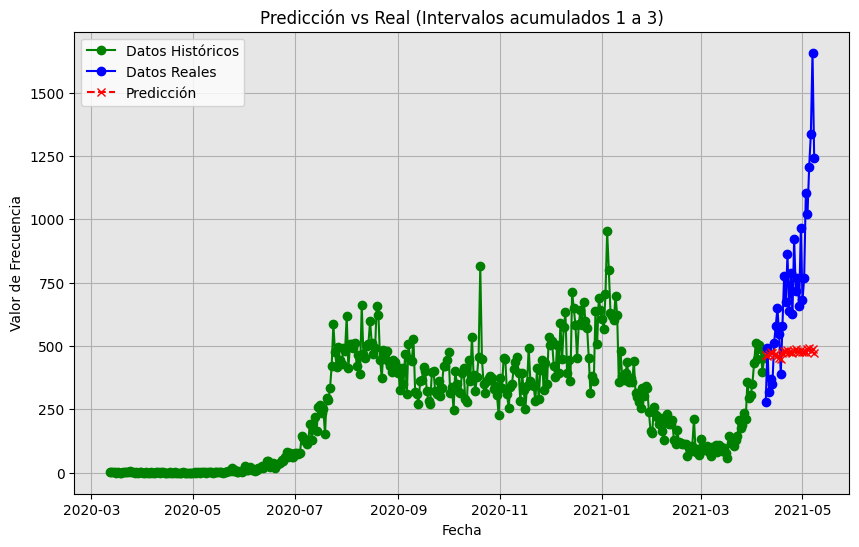

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 4: MAE = 41.80, MSE = 2038.77


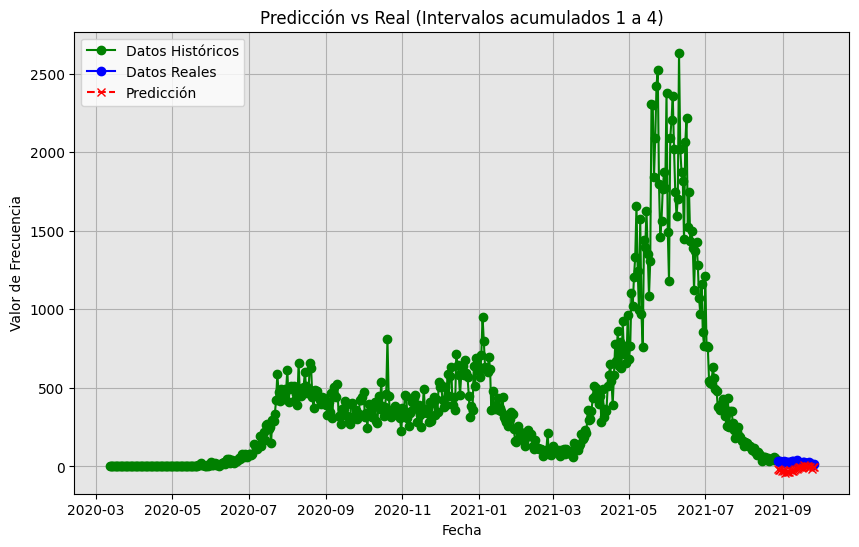

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 5: MAE = 385.63, MSE = 165428.20


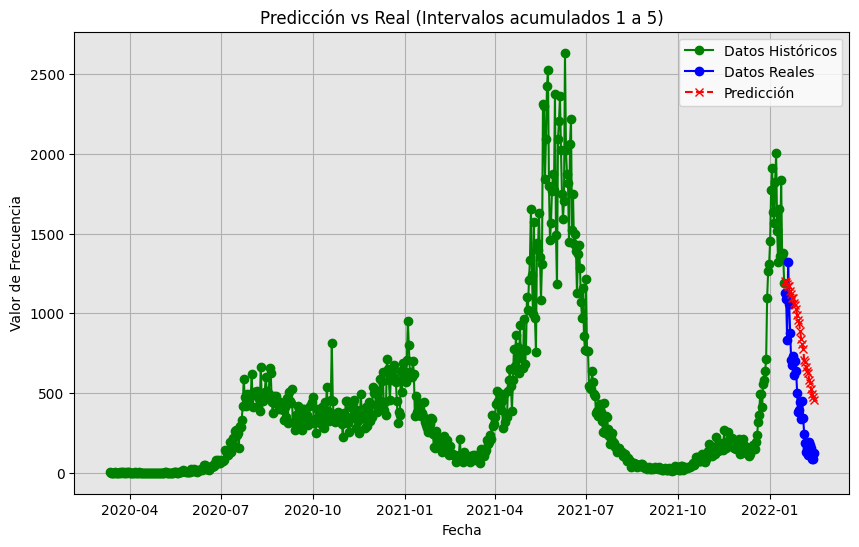

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 6: MAE = 151.10, MSE = 23289.37


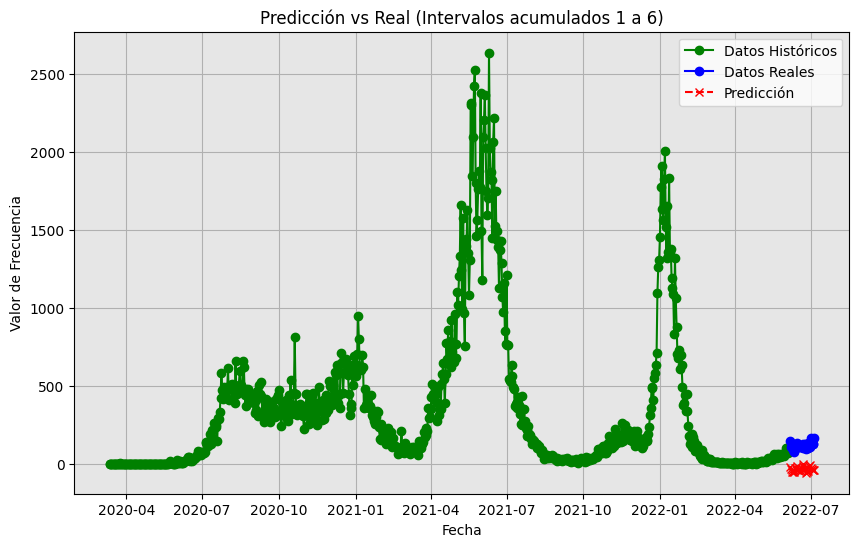

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 7: MAE = 416.36, MSE = 263496.67


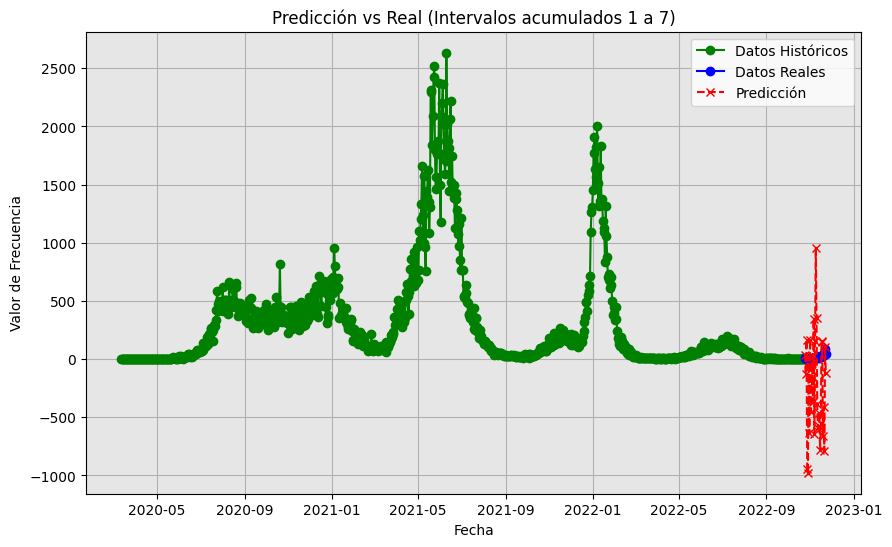

Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.
Acumulando intervalos 1 a 8: MAE = 61.51, MSE = 3840.70


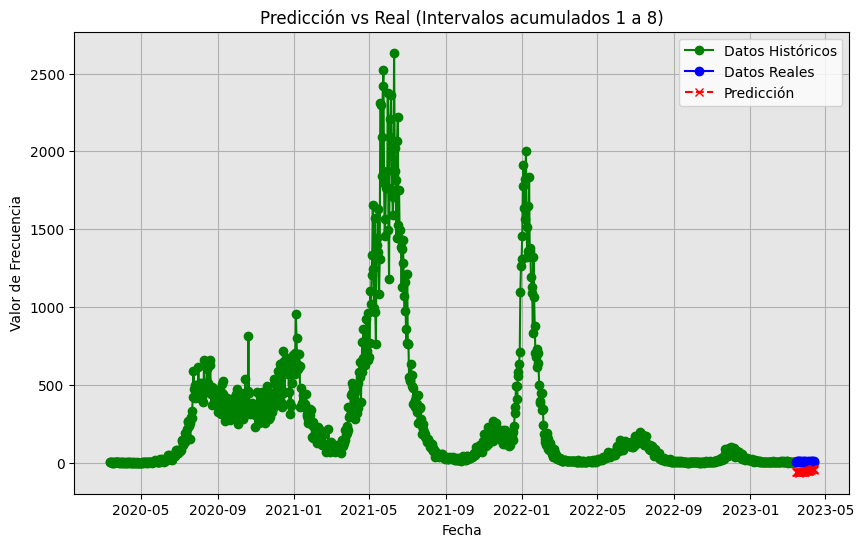


Resumen de métricas:
  Intervalos Acumulados         MAE            MSE       SMAPE
0      Intervalos 1 a 1  198.982635   63915.790876  106.295114
1      Intervalos 1 a 2  187.611755   54042.863092   49.261507
2      Intervalos 1 a 3  316.336490  172432.138545   45.571056
3      Intervalos 1 a 4   41.801022    2038.773090  194.287409
4      Intervalos 1 a 5  385.632291  165428.200357   73.704114
5      Intervalos 1 a 6  151.101156   23289.372383  199.846611
6      Intervalos 1 a 7  416.363839  263496.665838  182.115716
7      Intervalos 1 a 8   61.508628    3840.695782  200.000000


In [ ]:
# Parameters
HORIZONTE = 30


resultados = []

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend="gpu",
        per_core_batch_size=32,
        horizon_len=HORIZONTE,
        num_layers=50
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        version='torch',
        huggingface_repo_id="google/timesfm-2.0-500m-pytorch"),
)

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]

    df_final = df[df['Intervalo'].isin(intervalos_incluir)]
    
    series = df_final['Frecuencia'].values.reshape(-1, 1)

    # Inicializamos el escalador y escalamos la serie
    scaler = MinMaxScaler(feature_range=(0, 1))
    series_scaled = scaler.fit_transform(series)

    # Convertimos la serie escalada en un DataFrame
    df_scaled = pd.DataFrame(series_scaled, columns=['Frecuencia'])

    # Concatenamos la columna 'Fecha' con la columna escalada
    df_concatenado = pd.concat([df_final[['Fecha']].reset_index(drop=True), df_scaled], axis=1)

    df_train = df_concatenado.iloc[:-HORIZONTE].copy()
    df_test = df_concatenado.iloc[-HORIZONTE:].copy()

    # df_train = df_final.iloc[:-HORIZONTE].copy()
    # df_test = df_final.iloc[-HORIZONTE:].copy()

    # Preparing the data for training

    data_hist = df_train[['Fecha', 'Frecuencia']].rename(columns={
        'Fecha': 'ds',
        'Frecuencia': 'sales'
    })
    data_hist["unique_id"] = "series_1"

    forecast_df = tfm.forecast_on_df(
        inputs=data_hist,
        freq='D',
        forecast_context_len= len(data_hist),
        value_name='sales',
        num_jobs=-1)
    
    # 6. Alinear fechas y calcular métricas

    y_true = df_test['Frecuencia']
    y_pred = forecast_df['timesfm']
    
    y_pred = scaler.inverse_transform(y_pred.values.reshape(-1, 1))
    y_true = scaler.inverse_transform(y_true.values.reshape(-1, 1))


    # Calculamos las métricas
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    smape_value = smape(y_true, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos históricos, datos reales (test) y predicción sobre el intervalo completo
    fig, ax = plt.subplots(figsize=(10, 6))
    # Cambiar el color de fondo del eje a un gris suave
    ax.set_facecolor('#e6e6e6')  # Puedes ajustar el código hexadecimal para obtener el gris deseado

    # Graficar datos históricos (entrenamiento)
    # Aquí se vuelven a invertir las escalas para graficar los valores reales
    historico = scaler.inverse_transform(df_train['Frecuencia'].values.reshape(-1, 1))
    ax.plot(df_train['Fecha'], historico, label="Datos Históricos", marker='o', color='green')

    # Graficar datos reales del test (último intervalo)
    ax.plot(df_test['Fecha'], y_true, label="Datos Reales", marker='o', color='blue')

    # Graficar la predicción
    ax.plot(df_test['Fecha'], y_pred, label="Predicción", marker='x', linestyle='--', color='red')

    # Etiquetas y detalles de la gráfica
    ax.set_title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Valor de Frecuencia")
    ax.legend()
    ax.grid(True)

    plt.show()



df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 

df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_2/timesfm_30.csv', index=False)